# ***RTE***

# Main Gora

In [1]:
# ============================================================
# DeBERTa-v3-base + GoRA
# GLUE Sequence Classification
#
# Pure GoRA implementation
#
# Training configuration:
#   reference rank = 3
#   minimum rank  = 1
#   maximum rank  = 32
#   probe batches  = 64
#   LoRA alpha     = 16
#   learning rate  = 5e-4
#   max steps      = 1500
#   grad clipping  = 1.0
#   FP32
#
#
# GoRA is used for:
#   1. Gradient probing
#   2. Importance calculation
#   3. Rank allocation
#   4. Gradient-based LoRA initialization
#   5. Standard fixed-rank training afterwards
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip install -q -U transformers datasets peft accelerate sentencepiece scikit-learn
!pip install -U "torchao>=0.16.0"


# ============================================================
# 2. IMPORTS
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 3. REPRODUCIBILITY / DEVICE
# ============================================================

SEED = 87

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Device:", device)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# FP32 numerical stability
# ------------------------------------------------------------

torch.set_float32_matmul_precision("high")


# ============================================================
# 4. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"


# ------------------------------------------------------------
# GLUE task
# ------------------------------------------------------------

DATASET_NAME = "rte"


# Available:
#
# "cola"
# "sst2"
# "mrpc"
# "rte"
# "qnli"
# "mnli"


# ------------------------------------------------------------
# GoRA rank configuration
# ------------------------------------------------------------

REFERENCE_RANK = 3

MIN_RANK = 1

MAX_RANK = 32

N_PROBE_BATCHES = 64


# ------------------------------------------------------------
# LoRA / GoRA
# ------------------------------------------------------------

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GAMMA = 5e-2


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

LEARNING_RATE = 5e-4

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10


# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_LENGTH = 128


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

BETA1 = 0.9

BETA2 = 0.999

WEIGHT_DECAY = 0.0


# ------------------------------------------------------------
# Numerical stability
# ------------------------------------------------------------

GRAD_CLIP_NORM = 1.0

EPS = 1e-6


# ============================================================
# 5. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


print()
print("=" * 70)

print("Experiment:")

print(
    f"DeBERTa-v3-base + GoRA + "
    f"{DATASET_NAME.upper()}"
)

print("=" * 70)

print()


# ============================================================
# 6. PRINT EXPERIMENT CONFIGURATION
# ============================================================

print("Configuration:")
print()

print("Model:", MODEL_NAME)

print("Task:", DATASET_NAME)

print("Reference rank:", REFERENCE_RANK)

print("Minimum rank:", MIN_RANK)

print("Maximum rank:", MAX_RANK)

print("Probe batches:", N_PROBE_BATCHES)

print("LoRA alpha:", LORA_ALPHA)

print("GoRA gamma:", GAMMA)

print("Learning rate:", LEARNING_RATE)

print("Batch size:", BATCH_SIZE)

print("Maximum steps:", MAX_STEPS)

print("Warmup ratio:", WARMUP_RATIO)

print("Gradient clipping:", GRAD_CLIP_NORM)

print("Max sequence length:", MAX_LENGTH)

print("FP16: False")

print()


# ============================================================
# 7. LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")


# ============================================================
# 8. LOAD MODEL
# ============================================================

base_model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=NUM_LABELS,

)


# ------------------------------------------------------------
# Force FP32
# ------------------------------------------------------------

base_model = base_model.float()


print(
    "Model parameter dtype:",
    next(base_model.parameters()).dtype
)

print("Model loaded.")

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Hidden size:",
    base_model.config.hidden_size
)

print(
    "Number of layers:",
    base_model.config.num_hidden_layers
)

print(
    "Attention heads:",
    base_model.config.num_attention_heads
)


# ============================================================
# 9. LOAD GLUE DATASET
# ============================================================

raw_dataset = load_dataset(

    config["dataset"],

    config["subset"],

)


print()

print("Dataset:")

print(raw_dataset)


# ============================================================
# 10. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded


# ============================================================
# 11. TOKENIZE DATA
# ============================================================

tokenized_train = raw_dataset[
    "train"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,

)


if DATASET_NAME == "mnli":

    validation_split = "validation_matched"

else:

    validation_split = "validation"


tokenized_validation = raw_dataset[
    validation_split
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        validation_split
    ].column_names,

)


print()

print(
    "Training examples:",
    len(tokenized_train)
)

print(
    "Validation examples:",
    len(tokenized_validation)
)


# ============================================================
# 12. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,

        ),

    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


print()

print(
    "Training batches per epoch:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(eval_dataloader)
)


# ============================================================
# 13. VALIDATION LABELS
# ============================================================

true_labels = [

    int(example["label"])

    for example in raw_dataset[
        validation_split
    ]

]


# ============================================================
# 14. MOVE BASE MODEL TO DEVICE
# ============================================================

base_model = base_model.to(device)


# ============================================================
# 15. BASE MODEL SANITY CHECK
# ============================================================

base_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = base_model(
        **batch_device
    )


base_loss = outputs.loss

base_logits = outputs.logits


print()

print("=" * 70)

print("BASE MODEL SANITY CHECK")

print("=" * 70)


print(
    "Initial loss:",
    base_loss.item()
)


print(
    "Initial logits:"
)


print(
    base_logits[:3]
)


assert torch.isfinite(
    base_loss
).item(), (

    "BASE MODEL LOSS IS NaN/INF"

)


assert torch.isfinite(
    base_logits
).all().item(), (

    "BASE MODEL LOGITS CONTAIN NaN/INF"

)


print(
    "✓ Base model sanity check passed."
)


# ============================================================
# 16. FIND DEBERTA LINEAR LAYERS
#
# Exclude:
#   - classifier
#   - pooler
#
# GoRA is applied to the backbone.
# ============================================================

linear_modules = {}


for name, module in base_model.named_modules():

    if not isinstance(
        module,
        nn.Linear
    ):

        continue


    if name.startswith(
        "classifier"
    ):

        continue


    if name.startswith(
        "pooler"
    ):

        continue


    linear_modules[name] = module


print()

print("=" * 70)

print("TARGET LINEAR LAYERS")

print("=" * 70)


print(

    "Number of target linear layers:",

    len(linear_modules)

)


for name, module in linear_modules.items():

    print(

        f"{name:75s}",

        tuple(module.weight.shape)

    )


# ============================================================
# 17. GRADIENT PROBING
# ============================================================

def run_gradient_probe(

    model,

    probe_dataloader,

    target_modules,

    n_batches=64,

    device="cuda",

):

    model = model.to(device)

    model.train()


    # --------------------------------------------------------
    # Freeze everything
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    # --------------------------------------------------------
    # Enable target weights
    # --------------------------------------------------------

    probe_params = {}


    for name, module in target_modules.items():

        module.weight.requires_grad_(True)

        probe_params[name] = module.weight


    # --------------------------------------------------------
    # Gradient accumulators
    # --------------------------------------------------------

    accumulated_grads = {

        name: torch.zeros(

            param.shape,

            dtype=torch.float32,

            device="cpu",

        )

        for name, param
        in probe_params.items()

    }


    batches_used = 0


    # --------------------------------------------------------
    # Probe batches
    # --------------------------------------------------------

    for batch_idx, batch in enumerate(
        probe_dataloader
    ):


        if batch_idx >= n_batches:

            break


        batches_used += 1


        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        for param in probe_params.values():

            param.grad = None


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Finite loss check
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(

                f"NaN/Inf loss during "
                f"gradient probe at batch "
                f"{batch_idx}. "
                f"Loss={loss.item()}"

            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Collect gradients
        # ----------------------------------------------------

        for name, param in probe_params.items():

            if param.grad is None:

                continue


            grad = param.grad.detach()


            if not torch.isfinite(
                grad
            ).all():

                raise RuntimeError(

                    f"NaN/Inf gradient in "
                    f"{name} during probe "
                    f"at batch {batch_idx}."

                )


            accumulated_grads[name] += (

                grad

                .float()

                .cpu()

            )


            param.grad = None


        if (

            (batch_idx + 1) % 8 == 0

        ):

            print(

                f"Gradient probe: "
                f"{batch_idx + 1}/"
                f"{n_batches}"

            )


    if batches_used == 0:

        raise RuntimeError(

            "No batches were used for "
            "gradient probing."

        )


    # --------------------------------------------------------
    # Average gradients
    # --------------------------------------------------------

    for name in accumulated_grads:

        accumulated_grads[name] /= (

            float(batches_used)

        )


    # --------------------------------------------------------
    # Freeze everything again
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    print()

    print(

        f"Gradient probing finished. "
        f"Batches used: {batches_used}"

    )


    return accumulated_grads


# ============================================================
# 18. RUN GRADIENT PROBE
# ============================================================

accumulated_grads = run_gradient_probe(

    model=base_model,

    probe_dataloader=train_dataloader,

    target_modules=linear_modules,

    n_batches=N_PROBE_BATCHES,

    device=device,

)


# ============================================================
# 19. GRADIENT SANITY CHECK
# ============================================================

print()

print("=" * 70)

print("GRADIENT SANITY CHECK")

print("=" * 70)


print(

    "Number of gradient tensors:",

    len(accumulated_grads)

)


for name, grad in list(
    accumulated_grads.items()
)[:5]:

    print(

        name,

        "| shape:",

        tuple(grad.shape),

        "| norm:",

        grad.norm().item(),

    )


    assert torch.isfinite(
        grad
    ).all().item(), (

        f"NaN/Inf gradient in {name}"

    )


print(
    "✓ Gradient sanity check passed."
)


# ============================================================
# 20. COMPUTE GoRA IMPORTANCE
# ============================================================

def compute_gora_importance(

    accumulated_grads,

    target_modules,

):

    importance = {}


    for name, grad in accumulated_grads.items():

        weight = target_modules[
            name
        ].weight.detach()


        weight_cpu = (

            weight

            .float()

            .cpu()

        )


        # ----------------------------------------------------
        # GoRA importance
        # ----------------------------------------------------

        score = (

            weight_cpu * grad

        ).abs().mean().item()


        if not math.isfinite(score):

            raise RuntimeError(

                f"Non-finite importance "
                f"for {name}"

            )


        importance[name] = score


    return importance


# ============================================================
# 21. CALCULATE IMPORTANCE
# ============================================================

importance = compute_gora_importance(

    accumulated_grads,

    linear_modules,

)


sorted_importance = sorted(

    importance.items(),

    key=lambda x: x[1],

    reverse=True,

)


print()

print("=" * 70)

print("TOP IMPORTANT LAYERS")

print("=" * 70)


for name, score in sorted_importance[:20]:

    print(

        f"{score:.8e}  {name}"

    )


# ============================================================
# 22. RANK ALLOCATION
# ============================================================

def allocate_gora_ranks(

    target_modules,

    importance,

    reference_rank=3,

    min_rank=1,

    max_rank=32,

):

    total_importance = sum(

        importance.values()

    )


    if not math.isfinite(
        total_importance
    ):

        raise RuntimeError(

            "Total importance is NaN/Inf."

        )


    if total_importance <= 0:

        raise RuntimeError(

            "Total importance is zero. "
            "Cannot allocate GoRA ranks."

        )


    # --------------------------------------------------------
    # Normalize importance
    # --------------------------------------------------------

    advantages = {

        name:

        score / total_importance

        for name, score

        in importance.items()

    }


    # --------------------------------------------------------
    # Total parameter budget
    #
    # Reference rank = 3
    # --------------------------------------------------------

    total_budget = 0.0


    for name, module in target_modules.items():

        m, n = module.weight.shape


        total_budget += (

            math.sqrt(m)

            +

            math.sqrt(n)

        ) * reference_rank


    # --------------------------------------------------------
    # Allocate ranks
    # --------------------------------------------------------

    rank_pattern = {}


    for name, module in target_modules.items():

        m, n = module.weight.shape


        denominator = (

            math.sqrt(m)

            +

            math.sqrt(n)

        )


        raw_rank = (

            total_budget

            *

            advantages[name]

            /

            denominator

        )


        rank = round(
            raw_rank
        )


        rank = max(

            min_rank,

            min(

                max_rank,

                rank

            )

        )


        rank_pattern[name] = int(
            rank
        )


    return (

        rank_pattern,

        advantages,

        total_budget,

    )


# ============================================================
# 23. ALLOCATE RANKS
# ============================================================

rank_pattern, advantages, total_budget = (

    allocate_gora_ranks(

        target_modules=linear_modules,

        importance=importance,

        reference_rank=REFERENCE_RANK,

        min_rank=MIN_RANK,

        max_rank=MAX_RANK,

    )

)


# ============================================================
# 24. RANK SUMMARY
# ============================================================

rank_values = list(
    rank_pattern.values()
)


print()

print("=" * 70)

print("RANK ALLOCATION")

print("=" * 70)


print(

    "Number of adapted layers:",

    len(rank_values)

)


print(

    "Minimum rank:",

    min(rank_values)

)


print(

    "Maximum rank:",

    max(rank_values)

)


print(

    "Mean rank:",

    np.mean(rank_values)

)


print(

    "Reference rank:",

    REFERENCE_RANK

)


print()

print("Rank distribution:")


from collections import Counter


rank_distribution = Counter(
    rank_values
)


for rank in sorted(
    rank_distribution
):

    print(

        f"r={rank:2d}: "
        f"{rank_distribution[rank]} layers"

    )


# ============================================================
# 25. COUNT GoRA PARAMETERS
# ============================================================

def count_lora_parameters(

    target_modules,

    rank_pattern,

):

    total = 0


    for name, module in target_modules.items():

        m, n = module.weight.shape

        r = rank_pattern[name]


        total += r * (
            m + n
        )


    return total


gora_parameter_count = (

    count_lora_parameters(

        linear_modules,

        rank_pattern,

    )

)


print()

print(

    "GoRA parameter count:",

    f"{gora_parameter_count:,}"

)


# ============================================================
# 26. BUILD PEFT GoRA MODEL
# ============================================================

def build_gora_model(

    base_model,

    rank_pattern,

):

    lora_config = LoraConfig(

        # ----------------------------------------------------
        # Reference/default rank
        # ----------------------------------------------------

        r=REFERENCE_RANK,


        # ----------------------------------------------------
        # Scaling
        # ----------------------------------------------------

        lora_alpha=LORA_ALPHA,


        # ----------------------------------------------------
        # No dropout
        # ----------------------------------------------------

        lora_dropout=LORA_DROPOUT,


        # ----------------------------------------------------
        # No bias training
        # ----------------------------------------------------

        bias="none",


        # ----------------------------------------------------
        # Sequence classification
        # ----------------------------------------------------

        task_type="SEQ_CLS",


        # ----------------------------------------------------
        # DeBERTa linear layers
        # ----------------------------------------------------

        target_modules="all-linear",


        # ----------------------------------------------------
        # GoRA adaptive rank pattern
        # ----------------------------------------------------

        rank_pattern=rank_pattern,

    )


    model = get_peft_model(

        base_model,

        lora_config,

    )


    return model


# ============================================================
# 27. CREATE GoRA MODEL
# ============================================================

gora_model = build_gora_model(

    base_model,

    rank_pattern,

)


gora_model = gora_model.float()


print()

print("=" * 70)

print("PEFT GoRA MODEL")

print("=" * 70)


gora_model.print_trainable_parameters()


# ============================================================
# 28. NUMERICALLY-STABLE GoRA INITIALIZATION
# ============================================================

@torch.no_grad()
def initialize_gora(

    peft_model,

    accumulated_grads,

    gamma=0.05,

    lora_alpha=16,

    eps=1e-6,

):

    initialized = 0


    # --------------------------------------------------------
    # Iterate through PEFT modules
    # --------------------------------------------------------

    for name, module in peft_model.named_modules():

        if not hasattr(
            module,
            "lora_A"
        ):

            continue


        # ----------------------------------------------------
        # Find original module name
        # ----------------------------------------------------

        matches = [

            original_name

            for original_name

            in accumulated_grads

            if name.endswith(
                original_name
            )

        ]


        if len(matches) == 0:

            continue


        original_name = matches[0]


        G_cpu = accumulated_grads[
            original_name
        ]


        # ----------------------------------------------------
        # PEFT matrices
        # ----------------------------------------------------

        A = module.lora_A[
            "default"
        ].weight


        B = module.lora_B[
            "default"
        ].weight


        # ----------------------------------------------------
        # FP32 calculations
        # ----------------------------------------------------

        A_fp32 = A.float()


        G_fp32 = (

            G_cpu

            .float()

            .to(
                device=A.device
            )

        )


        # ----------------------------------------------------
        # Gradient check
        # ----------------------------------------------------

        if not torch.isfinite(
            G_fp32
        ).all():

            raise RuntimeError(

                f"Non-finite gradient "
                f"for {original_name}"

            )


        # ----------------------------------------------------
        # Initialize A
        # ----------------------------------------------------

        nn.init.kaiming_uniform_(

            A_fp32,

            a=math.sqrt(5),

        )


        # ----------------------------------------------------
        # Calculate A A^T
        # ----------------------------------------------------

        AA_T = (

            A_fp32

            @

            A_fp32.T

        )


        r = AA_T.shape[0]


        identity = torch.eye(

            r,

            device=A.device,

            dtype=torch.float32,

        )


        # ----------------------------------------------------
        # Regularization
        # ----------------------------------------------------

        regularized = (

            AA_T

            +

            eps * identity

        )


        # ----------------------------------------------------
        # Solve instead of inverse
        # ----------------------------------------------------

        try:

            inverse = torch.linalg.solve(

                regularized,

                identity,

            )

        except RuntimeError:

            print(

                "Warning: solve() failed for",

                original_name,

                "- using pinv()."

            )


            inverse = torch.linalg.pinv(

                regularized

            )


        # ----------------------------------------------------
        # GoRA initialization
        #
        # B = -G A^T (AA^T)^-1
        # ----------------------------------------------------

        B_fp32 = (

            -G_fp32

            @

            A_fp32.T

            @

            inverse

        )


        # ----------------------------------------------------
        # GoRA scaling
        # ----------------------------------------------------

        m = G_fp32.shape[0]


        scaling = (

            gamma

            *

            math.sqrt(m)

            /

            lora_alpha

        )


        B_fp32 = (

            B_fp32

            *

            scaling

        )


        # ----------------------------------------------------
        # Finite checks
        # ----------------------------------------------------

        if not torch.isfinite(
            A_fp32
        ).all():

            raise RuntimeError(

                f"A became NaN/Inf "
                f"in {original_name}"

            )


        if not torch.isfinite(
            B_fp32
        ).all():

            raise RuntimeError(

                f"B became NaN/Inf "
                f"in {original_name}"

            )


        # ----------------------------------------------------
        # Copy back
        # ----------------------------------------------------

        A.copy_(

            A_fp32.to(
                dtype=A.dtype
            )

        )


        B.copy_(

            B_fp32.to(
                dtype=B.dtype
            )

        )


        initialized += 1


    print()

    print(

        f"Initialized "
        f"{initialized} GoRA layers."

    )


    return initialized


# ============================================================
# 29. INITIALIZE GoRA
# ============================================================

initialized_layers = initialize_gora(

    peft_model=gora_model,

    accumulated_grads=accumulated_grads,

    gamma=GAMMA,

    lora_alpha=LORA_ALPHA,

    eps=EPS,

)


assert initialized_layers > 0, (

    "No GoRA layers were initialized."

)


# ============================================================
# 30. CHECK GoRA MATRICES
# ============================================================

print()

print("=" * 70)

print("GoRA MATRIX SANITY CHECK")

print("=" * 70)


checked = 0


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    A = module.lora_A[
        "default"
    ].weight


    B = module.lora_B[
        "default"
    ].weight


    A_norm = (

        A.detach()

        .float()

        .norm()

        .item()

    )


    B_norm = (

        B.detach()

        .float()

        .norm()

        .item()

    )


    print(name)

    print(

        "  A shape:",

        tuple(A.shape)

    )


    print(

        "  B shape:",

        tuple(B.shape)

    )


    print(

        "  A norm:",

        A_norm

    )


    print(

        "  B norm:",

        B_norm

    )


    assert math.isfinite(
        A_norm
    )


    assert math.isfinite(
        B_norm
    )


    checked += 1


    if checked >= 10:

        break


print()

print(
    "✓ GoRA initialization is finite."
)


# ============================================================
# 31. CHECK ACTUAL PEFT RANKS
# ============================================================

print()

print("=" * 70)

print("ACTUAL PEFT RANKS")

print("=" * 70)


rank_count = 0


actual_rank_values = []


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    actual_rank = (

        module.lora_A[
            "default"
        ].weight.shape[0]

    )


    actual_rank_values.append(
        actual_rank
    )


    print(

        f"r={actual_rank:2d}  {name}"

    )


    rank_count += 1


print()

print(

    "Number of LoRA modules:",

    rank_count

)


print(

    "Mean actual rank:",

    np.mean(actual_rank_values)

)


# ============================================================
# 32. MOVE GoRA MODEL TO DEVICE
# ============================================================

gora_model = gora_model.to(
    device
)


# ============================================================
# 33. POST-GoRA SANITY CHECK
# ============================================================

gora_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = gora_model(
        **batch_device
    )


gora_initial_loss = outputs.loss

gora_initial_logits = outputs.logits


print()

print("=" * 70)

print("POST-GoRA FIRST FORWARD PASS")

print("=" * 70)


print(

    "GoRA initial loss:",

    gora_initial_loss.item()

)


print(

    "GoRA initial logits:"

)


print(

    gora_initial_logits[:5]

)


assert torch.isfinite(

    gora_initial_loss

).item(), (

    "CRITICAL: GoRA initial "
    "loss is NaN/Inf."

)


assert torch.isfinite(

    gora_initial_logits

).all().item(), (

    "CRITICAL: GoRA initial "
    "logits contain NaN/Inf."

)


print()

print(

    "✓ GoRA first forward pass "
    "is numerically stable."

)


# ============================================================
# 34. CREATE OPTIMIZER
#
# IMPORTANT:
# A and B use THE SAME learning rate.
#
# This makes the comparison with standard LoRA fair.
# ============================================================

def create_gora_optimizer(

    model,

    learning_rate=5e-4,

):

    trainable_params = [

        param

        for param in model.parameters()

        if param.requires_grad

    ]


    print()

    print(

        "Trainable parameters:",

        sum(
            p.numel()
            for p in trainable_params
        )

    )


    optimizer = AdamW(

        trainable_params,

        lr=learning_rate,

        betas=(

            BETA1,

            BETA2,

        ),

        weight_decay=WEIGHT_DECAY,

        eps=1e-8,

    )


    return optimizer


# ============================================================
# 35. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(

    model,

    eval_dataloader,

    true_labels,

    device,

):

    model.eval()


    all_predictions = []

    all_losses = []


    for batch in eval_dataloader:

        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(

                "NaN/Inf validation loss."

            )


        predictions = (

            outputs.logits

            .argmax(

                dim=-1

            )

            .cpu()

            .tolist()

        )


        all_predictions.extend(
            predictions
        )


        all_losses.append(
            loss.item()
        )


    accuracy = accuracy_score(

        true_labels,

        all_predictions,

    )


    if config["metric"] == "matthews":

        primary_metric = matthews_corrcoef(

            true_labels,

            all_predictions,

        )

    else:

        primary_metric = accuracy


    f1 = f1_score(

        true_labels,

        all_predictions,

        average="weighted",

    )


    avg_loss = np.mean(
        all_losses
    )


    return (

        primary_metric,

        accuracy,

        f1,

        avg_loss,

        all_predictions,

    )


# ============================================================
# 36. TRAINING
# ============================================================

def train_gora(

    model,

    train_dataloader,

    eval_dataloader,

    true_labels,

    device,

):

    model = model.to(device)


    # --------------------------------------------------------
    # EXACTLY 1500 optimization steps
    # --------------------------------------------------------

    total_steps = MAX_STEPS


    warmup_steps = max(

        1,

        math.ceil(

            total_steps

            *

            WARMUP_RATIO

        )

    )


    print()

    print("=" * 70)

    print("TRAINING CONFIGURATION")

    print("=" * 70)


    print(

        "Total training steps:",

        total_steps

    )


    print(

        "Warmup steps:",

        warmup_steps

    )


    print(

        "Learning rate:",

        LEARNING_RATE

    )


    print(

        "Batch size:",

        BATCH_SIZE

    )


    print(

        "Gradient clipping:",

        GRAD_CLIP_NORM

    )


    print(

        "Optimizer: AdamW"

    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = create_gora_optimizer(

        model,

        learning_rate=LEARNING_RATE,

    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = (

        get_cosine_schedule_with_warmup(

            optimizer,

            num_warmup_steps=warmup_steps,

            num_training_steps=total_steps,

        )

    )


    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats(
            device
        )


    train_start = time.time()


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    global_step = 0

    epoch = 0


    while global_step < MAX_STEPS:

        epoch += 1

        model.train()


        epoch_loss = 0.0

        epoch_steps = 0


        for step, batch in enumerate(
            train_dataloader
        ):


            if global_step >= MAX_STEPS:

                break


            global_step += 1


            batch = {

                key: value.to(

                    device,

                    non_blocking=True,

                )

                for key, value in batch.items()

            }


            # ------------------------------------------------
            # Clear gradients
            # ------------------------------------------------

            optimizer.zero_grad(

                set_to_none=True

            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                **batch
            )


            loss = outputs.loss


            # ------------------------------------------------
            # NaN / Inf check
            # ------------------------------------------------

            if not torch.isfinite(loss):

                print()

                print(
                    "CRITICAL NUMERICAL ERROR"
                )


                print(
                    "Epoch:",
                    epoch
                )


                print(
                    "Step:",
                    global_step
                )


                print(
                    "Loss:",
                    loss.item()
                )


                raise RuntimeError(

                    "NaN/Inf loss encountered."

                )


            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            grad_norm = (

                torch.nn.utils

                .clip_grad_norm_(

                    model.parameters(),

                    GRAD_CLIP_NORM,

                )

            )


            if not torch.isfinite(
                grad_norm
            ):

                raise RuntimeError(

                    "Gradient norm became "
                    "NaN/Inf."

                )


            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # Scheduler
            # ------------------------------------------------

            scheduler.step()


            epoch_loss += loss.item()

            epoch_steps += 1


            # ------------------------------------------------
            # Monitoring
            # ------------------------------------------------

            if (

                global_step == 1

                or

                global_step % 25 == 0

                or

                global_step == MAX_STEPS

            ):


                current_lr = (

                    optimizer

                    .param_groups[0]["lr"]

                )


                print(

                    f"Epoch "
                    f"{epoch} "

                    f"| Step "
                    f"{global_step}/"
                    f"{MAX_STEPS} "

                    f"| loss="
                    f"{loss.item():.6f} "

                    f"| grad="
                    f"{grad_norm:.4f} "

                    f"| LR="
                    f"{current_lr:.2e}"

                )


        # ----------------------------------------------------
        # Epoch summary
        # ----------------------------------------------------

        if epoch_steps > 0:

            avg_loss = (

                epoch_loss

                /

                epoch_steps

            )


            print()

            print(

                f"Epoch "
                f"{epoch} "

                f"| average loss="
                f"{avg_loss:.6f}"

            )


    # ========================================================
    # TRAINING TIME
    # ========================================================

    train_time = (

        time.time()

        -

        train_start

    )


    # ========================================================
    # EVALUATION
    # ========================================================

    (

        primary_metric,

        accuracy,

        f1,

        eval_loss,

        predictions,

    ) = evaluate(

        model,

        eval_dataloader,

        true_labels,

        device,

    )


    # ========================================================
    # GPU MEMORY
    # ========================================================

    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda

            .max_memory_allocated(

                device

            )

            /

            1e9

        )

    else:

        peak_memory = 0.0


    # ========================================================
    # PARAMETER COUNTS
    # ========================================================

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )


    total_params = sum(

        p.numel()

        for p in model.parameters()

    )


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print()

    print("=" * 70)

    print(
        "FINAL GoRA + DeBERTa-v3-base RESULTS"
    )

    print("=" * 70)


    print(

        f"Task:              "
        f"{DATASET_NAME.upper()}"

    )


    print(

        f"Primary metric:    "
        f"{primary_metric:.4f}"

    )


    print(

        f"Accuracy:          "
        f"{accuracy:.4f}"

    )


    print(

        f"F1:                "
        f"{f1:.4f}"

    )


    print(

        f"Evaluation loss:   "
        f"{eval_loss:.6f}"

    )


    print(

        f"Trainable params:  "
        f"{trainable_params:,}"

    )


    print(

        f"Trainable %:       "
        f"{100 * trainable_params / total_params:.4f}%"

    )


    print(

        f"Training steps:    "
        f"{MAX_STEPS}"

    )


    print(

        f"Training time:     "
        f"{train_time:.1f} seconds"

    )


    print(

        f"Peak GPU memory:   "
        f"{peak_memory:.2f} GB"

    )


    print("=" * 70)


    return {

        "task":
            DATASET_NAME,

        "model":
            MODEL_NAME,

        "primary_metric":
            primary_metric,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "eval_loss":
            eval_loss,

        "train_time":
            train_time,

        "peak_memory_gb":
            peak_memory,

        "trainable_params":
            trainable_params,

        "total_params":
            total_params,

        "predictions":
            predictions,

        "rank_pattern":
            rank_pattern,

    }


# ============================================================
# 37. RUN TRAINING
# ============================================================

gora_results = train_gora(

    model=gora_model,

    train_dataloader=train_dataloader,

    eval_dataloader=eval_dataloader,

    true_labels=true_labels,

    device=device,

)


# ============================================================
# 38. FINAL RESULT OBJECT
# ============================================================

print()

print("=" * 70)

print("EXPERIMENT FINISHED")

print("=" * 70)


print(
    gora_results
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 59.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Device: cuda
GPU: Tesla T4
CUDA: 12.8

Experiment:
DeBERTa-v3-base + GoRA + RTE

Configuration:

Model: microsoft/deberta-v3-base
Task: rte
Reference rank: 3
Minimum rank: 1
Maximum rank: 32
Probe batches: 64
LoRA alpha: 16
GoRA gamma: 0.05
Learning rate: 0.0005
Batch size: 16
Maximum steps: 1500
Warmup ratio: 0.1
Gradient clipping: 1.0
Max sequence length: 128
FP16: False



config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

...

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/277 [00:00<?, ? examples/s]


Training examples: 2490
Validation examples: 277

Training batches per epoch: 156
Validation batches: 18

BASE MODEL SANITY CHECK
Initial loss: 0.6889971494674683
Initial logits:
tensor([[ 0.0828, -0.0021],
        [ 0.0865, -0.0017],
        [ 0.0862, -0.0022]], device='cuda:0')
✓ Base model sanity check passed.

TARGET LINEAR LAYERS
Number of target linear layers: 72
deberta.encoder.layer.0.attention.self.query_proj                           (768, 768)
deberta.encoder.layer.0.attention.self.key_proj                             (768, 768)
deberta.encoder.layer.0.attention.self.value_proj                           (768, 768)
deberta.encoder.layer.0.attention.output.dense                              (768, 768)
deberta.encoder.layer.0.intermediate.dense                                  (3072, 768)
deberta.encoder.layer.0.output.dense                                        (768, 3072)
deberta.encoder.layer.1.attention.self.query_proj                           (768, 768)
deberta.encoder.

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



Initialized 72 GoRA layers.

GoRA MATRIX SANITY CHECK
base_model.model.deberta.encoder.layer.0.attention.self.query_proj
  A shape: (1, 768)
  B shape: (768, 1)
  A norm: 0.574088990688324
  B norm: 5.450700655273977e-07
base_model.model.deberta.encoder.layer.0.attention.self.key_proj
  A shape: (1, 768)
  B shape: (768, 1)
  A norm: 0.5945848822593689
  B norm: 5.214799898567435e-07
base_model.model.deberta.encoder.layer.0.attention.self.value_proj
  A shape: (1, 768)
  B shape: (768, 1)
  A norm: 0.5688304901123047
  B norm: 1.8452449239703128e-06
base_model.model.deberta.encoder.layer.0.attention.output.dense
  A shape: (1, 768)
  B shape: (768, 1)
  A norm: 0.5810441970825195
  B norm: 2.697348918445641e-06
base_model.model.deberta.encoder.layer.0.intermediate.dense
  A shape: (1, 768)
  B shape: (3072, 1)
  A norm: 0.581009566783905
  B norm: 7.79843503551092e-06
base_model.model.deberta.encoder.layer.0.output.dense
  A shape: (1, 3072)
  B shape: (768, 1)
  A norm: 0.57683694362

# Lora

In [2]:
# ============================================================
# DeBERTa-v3-base + Standard LoRA
# GLUE Sequence Classification
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 87

MODEL_NAME = "microsoft/deberta-v3-base"

DATASET_NAME = "rte"

MAX_LENGTH = 128

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10

LEARNING_RATE = 5e-4

LORA_RANK = 3

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GRAD_CLIP_NORM = 1.0


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


torch.set_float32_matmul_precision("high")


# ============================================================
# 3. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


# ============================================================
# 4. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 5. MODEL
# ============================================================

base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
    )
)

base_model = base_model.float()


# ============================================================
# 6. DATASET
# ============================================================

raw_dataset = load_dataset(
    config["dataset"],
    config["subset"],
)


# ============================================================
# 7. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2 = example[
        config["sentence2"]
    ]

    encoded = tokenizer(

        sentence1,

        sentence2,

        max_length=MAX_LENGTH,

        truncation=True,

        padding="max_length",
    )

    encoded["labels"] = int(
        example["label"]
    )

    return encoded


tokenized_train = raw_dataset["train"].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,
)


tokenized_validation = raw_dataset[
    "validation"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "validation"
    ].column_names,
)


true_labels = [

    int(example["label"])

    for example in raw_dataset[
        "validation"
    ]

]


# ============================================================
# 8. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,
        ),
    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 9. STANDARD LoRA
# ============================================================

lora_config = LoraConfig(

    r=LORA_RANK,

    lora_alpha=LORA_ALPHA,

    lora_dropout=LORA_DROPOUT,

    bias="none",

    task_type="SEQ_CLS",

    target_modules="all-linear",
)


model = get_peft_model(

    base_model,

    lora_config,
)


model = model.float()

model = model.to(device)


print()
print("=" * 70)
print("STANDARD LoRA")
print("=" * 70)

model.print_trainable_parameters()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    betas=(0.9, 0.999),

    weight_decay=0.0,

    eps=1e-8,
)


# ============================================================
# 11. SCHEDULER
# ============================================================

warmup_steps = max(

    1,

    math.ceil(
        MAX_STEPS * WARMUP_RATIO
    ),
)


scheduler = (
    get_cosine_schedule_with_warmup(

        optimizer,

        num_warmup_steps=warmup_steps,

        num_training_steps=MAX_STEPS,
    )
)


# ============================================================
# 12. TRAIN
# ============================================================

if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats(
        device
    )


train_start = time.time()

global_step = 0

epoch = 0


while global_step < MAX_STEPS:

    epoch += 1

    model.train()

    for batch in train_dataloader:

        if global_step >= MAX_STEPS:
            break

        global_step += 1

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"NaN/Inf loss at "
                f"step {global_step}"
            )


        loss.backward()


        grad_norm = (
            torch.nn.utils
            .clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
        )


        if not torch.isfinite(
            grad_norm
        ):

            raise RuntimeError(
                "Gradient norm became NaN/Inf."
            )


        optimizer.step()

        scheduler.step()


        if (

            global_step == 1

            or

            global_step % 25 == 0

            or

            global_step == MAX_STEPS

        ):

            print(

                f"Epoch {epoch} "

                f"| Step "
                f"{global_step}/"
                f"{MAX_STEPS} "

                f"| loss="
                f"{loss.item():.6f} "

                f"| grad="
                f"{grad_norm:.4f} "

                f"| LR="
                f"{scheduler.get_last_lr()[0]:.2e}"

            )


train_time = (
    time.time()
    - train_start
)


# ============================================================
# 13. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    dataloader,
):

    model.eval()

    predictions = []

    losses = []

    for batch in dataloader:

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                "NaN/Inf validation loss."
            )


        predictions.extend(

            outputs.logits
            .argmax(dim=-1)
            .cpu()
            .tolist()

        )


        losses.append(
            loss.item()
        )


    accuracy = accuracy_score(
        true_labels,
        predictions,
    )


    f1 = f1_score(

        true_labels,

        predictions,

        average="weighted",
    )


    avg_loss = np.mean(
        losses
    )


    return (
        accuracy,
        f1,
        avg_loss,
        predictions,
    )


accuracy, f1, eval_loss, predictions = evaluate(
    model,
    eval_dataloader,
)


# ============================================================
# 14. PARAMETER COUNTS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


if torch.cuda.is_available():

    peak_memory = (

        torch.cuda
        .max_memory_allocated(device)
        / 1e9

    )

else:

    peak_memory = 0.0


# ============================================================
# 15. RESULTS
# ============================================================

print()
print("=" * 70)
print("FINAL STANDARD LoRA + DeBERTa-v3-base RESULTS")
print("=" * 70)

print(
    f"Task:              {DATASET_NAME.upper()}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"F1:                {f1:.4f}"
)

print(
    f"Evaluation loss:   {eval_loss:.6f}"
)

print(
    f"Trainable params:  {trainable_params:,}"
)

print(
    f"Trainable %:       "
    f"{100 * trainable_params / total_params:.4f}%"
)

print(
    f"Training steps:    {MAX_STEPS}"
)

print(
    f"Training time:     {train_time:.1f} seconds"
)

print(
    f"Peak GPU memory:   {peak_memory:.2f} GB"
)

print("=" * 70)

Device: cuda
GPU: Tesla T4
CUDA: 12.8


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/277 [00:00<?, ? examples/s]


STANDARD LoRA
trainable params: 503,810 || all params: 184,927,492 || trainable%: 0.2724
Epoch 1 | Step 1/1500 | loss=0.700471 | grad=1.4179 | LR=3.33e-06
Epoch 1 | Step 25/1500 | loss=0.687989 | grad=0.7364 | LR=8.33e-05
Epoch 1 | Step 50/1500 | loss=0.700357 | grad=1.1370 | LR=1.67e-04
Epoch 1 | Step 75/1500 | loss=0.690300 | grad=0.5715 | LR=2.50e-04
Epoch 1 | Step 100/1500 | loss=0.684431 | grad=0.5439 | LR=3.33e-04
Epoch 1 | Step 125/1500 | loss=0.737210 | grad=3.1681 | LR=4.17e-04
Epoch 1 | Step 150/1500 | loss=0.686846 | grad=1.0838 | LR=5.00e-04
Epoch 2 | Step 175/1500 | loss=0.737505 | grad=1.6389 | LR=5.00e-04
Epoch 2 | Step 200/1500 | loss=0.716792 | grad=0.6580 | LR=4.98e-04
Epoch 2 | Step 225/1500 | loss=0.665951 | grad=1.9275 | LR=4.96e-04
Epoch 2 | Step 250/1500 | loss=0.744170 | grad=1.5089 | LR=4.93e-04
Epoch 2 | Step 275/1500 | loss=0.727612 | grad=1.4273 | LR=4.89e-04
Epoch 2 | Step 300/1500 | loss=0.714910 | grad=0.8560 | LR=4.85e-04
Epoch 3 | Step 325/1500 | loss=

# ***Cola***

# Main Gora

In [4]:
# ============================================================
# DeBERTa-v3-base + GoRA
# GLUE Sequence Classification
#
# Pure GoRA implementation
#
# Training configuration:
#   reference rank = 3
#   minimum rank  = 1
#   maximum rank  = 32
#   probe batches  = 64
#   LoRA alpha     = 16
#   learning rate  = 5e-4
#   max steps      = 1500
#   grad clipping  = 1.0
#   FP32
#
# GoRA is used for:
#   1. Gradient probing
#   2. Importance calculation
#   3. Rank allocation
#   4. Gradient-based LoRA initialization
#   5. Standard fixed-rank training afterwards
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip install -q -U transformers datasets peft accelerate sentencepiece scikit-learn
!pip install -U "torchao>=0.16.0"


# ============================================================
# 2. IMPORTS
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 3. REPRODUCIBILITY / DEVICE
# ============================================================

SEED = 87

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Device:", device)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# FP32 numerical stability
# ------------------------------------------------------------

torch.set_float32_matmul_precision("high")


# ============================================================
# 4. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"


# ------------------------------------------------------------
# GLUE task
# ------------------------------------------------------------

DATASET_NAME = "cola"


# Available:
#
# "cola"
# "sst2"
# "mrpc"
# "rte"
# "qnli"
# "mnli"


# ------------------------------------------------------------
# GoRA rank configuration
# ------------------------------------------------------------

REFERENCE_RANK = 3

MIN_RANK = 1

MAX_RANK = 32

N_PROBE_BATCHES = 64


# ------------------------------------------------------------
# LoRA / GoRA
# ------------------------------------------------------------

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GAMMA = 5e-2


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

LEARNING_RATE = 5e-4

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10


# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_LENGTH = 128


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

BETA1 = 0.9

BETA2 = 0.999

WEIGHT_DECAY = 0.0


# ------------------------------------------------------------
# Numerical stability
# ------------------------------------------------------------

GRAD_CLIP_NORM = 1.0

EPS = 1e-6


# ============================================================
# 5. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


print()
print("=" * 70)

print("Experiment:")

print(
    f"DeBERTa-v3-base + GoRA + "
    f"{DATASET_NAME.upper()}"
)

print("=" * 70)

print()


# ============================================================
# 6. PRINT EXPERIMENT CONFIGURATION
# ============================================================

print("Configuration:")
print()

print("Model:", MODEL_NAME)

print("Task:", DATASET_NAME)

print("Reference rank:", REFERENCE_RANK)

print("Minimum rank:", MIN_RANK)

print("Maximum rank:", MAX_RANK)

print("Probe batches:", N_PROBE_BATCHES)

print("LoRA alpha:", LORA_ALPHA)

print("GoRA gamma:", GAMMA)

print("Learning rate:", LEARNING_RATE)

print("Batch size:", BATCH_SIZE)

print("Maximum steps:", MAX_STEPS)

print("Warmup ratio:", WARMUP_RATIO)

print("Gradient clipping:", GRAD_CLIP_NORM)

print("Max sequence length:", MAX_LENGTH)

print("FP16: False")

print()


# ============================================================
# 7. LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")


# ============================================================
# 8. LOAD MODEL
# ============================================================

base_model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=NUM_LABELS,

)


# ------------------------------------------------------------
# Force FP32
# ------------------------------------------------------------

base_model = base_model.float()


print(
    "Model parameter dtype:",
    next(base_model.parameters()).dtype
)

print("Model loaded.")

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Hidden size:",
    base_model.config.hidden_size
)

print(
    "Number of layers:",
    base_model.config.num_hidden_layers
)

print(
    "Attention heads:",
    base_model.config.num_attention_heads
)


# ============================================================
# 9. LOAD GLUE DATASET
# ============================================================

raw_dataset = load_dataset(

    config["dataset"],

    config["subset"],

)


print()

print("Dataset:")

print(raw_dataset)


# ============================================================
# 10. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded


# ============================================================
# 11. TOKENIZE DATA
# ============================================================

tokenized_train = raw_dataset[
    "train"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,

)


if DATASET_NAME == "mnli":

    validation_split = "validation_matched"

else:

    validation_split = "validation"


tokenized_validation = raw_dataset[
    validation_split
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        validation_split
    ].column_names,

)


print()

print(
    "Training examples:",
    len(tokenized_train)
)

print(
    "Validation examples:",
    len(tokenized_validation)
)


# ============================================================
# 12. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,

        ),

    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


print()

print(
    "Training batches per epoch:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(eval_dataloader)
)


# ============================================================
# 13. VALIDATION LABELS
# ============================================================

true_labels = [

    int(example["label"])

    for example in raw_dataset[
        validation_split
    ]

]


# ============================================================
# 14. MOVE BASE MODEL TO DEVICE
# ============================================================

base_model = base_model.to(device)


# ============================================================
# 15. BASE MODEL SANITY CHECK
# ============================================================

base_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = base_model(
        **batch_device
    )


base_loss = outputs.loss

base_logits = outputs.logits


print()

print("=" * 70)

print("BASE MODEL SANITY CHECK")

print("=" * 70)


print(
    "Initial loss:",
    base_loss.item()
)


print(
    "Initial logits:"
)


print(
    base_logits[:3]
)


assert torch.isfinite(
    base_loss
).item(), (

    "BASE MODEL LOSS IS NaN/INF"

)


assert torch.isfinite(
    base_logits
).all().item(), (

    "BASE MODEL LOGITS CONTAIN NaN/INF"

)


print(
    "✓ Base model sanity check passed."
)


# ============================================================
# 16. FIND DEBERTA LINEAR LAYERS
#
# Exclude:
#   - classifier
#   - pooler
#
# GoRA is applied to the backbone.
# ============================================================

linear_modules = {}


for name, module in base_model.named_modules():

    if not isinstance(
        module,
        nn.Linear
    ):

        continue


    if name.startswith(
        "classifier"
    ):

        continue


    if name.startswith(
        "pooler"
    ):

        continue


    linear_modules[name] = module


print()

print("=" * 70)

print("TARGET LINEAR LAYERS")

print("=" * 70)


print(

    "Number of target linear layers:",

    len(linear_modules)

)


for name, module in linear_modules.items():

    print(

        f"{name:75s}",

        tuple(module.weight.shape)

    )


# ============================================================
# 17. GRADIENT PROBING
# ============================================================

def run_gradient_probe(

    model,

    probe_dataloader,

    target_modules,

    n_batches=64,

    device="cuda",

):

    model = model.to(device)

    model.train()


    # --------------------------------------------------------
    # Freeze everything
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    # --------------------------------------------------------
    # Enable target weights
    # --------------------------------------------------------

    probe_params = {}


    for name, module in target_modules.items():

        module.weight.requires_grad_(True)

        probe_params[name] = module.weight


    # --------------------------------------------------------
    # Gradient accumulators
    # --------------------------------------------------------

    accumulated_grads = {

        name: torch.zeros(

            param.shape,

            dtype=torch.float32,

            device="cpu",

        )

        for name, param
        in probe_params.items()

    }


    batches_used = 0


    # --------------------------------------------------------
    # Probe batches
    # --------------------------------------------------------

    for batch_idx, batch in enumerate(
        probe_dataloader
    ):


        if batch_idx >= n_batches:

            break


        batches_used += 1


        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        for param in probe_params.values():

            param.grad = None


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Finite loss check
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(

                f"NaN/Inf loss during "
                f"gradient probe at batch "
                f"{batch_idx}. "
                f"Loss={loss.item()}"

            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Collect gradients
        # ----------------------------------------------------

        for name, param in probe_params.items():

            if param.grad is None:

                continue


            grad = param.grad.detach()


            if not torch.isfinite(
                grad
            ).all():

                raise RuntimeError(

                    f"NaN/Inf gradient in "
                    f"{name} during probe "
                    f"at batch {batch_idx}."

                )


            accumulated_grads[name] += (

                grad

                .float()

                .cpu()

            )


            param.grad = None


        if (

            (batch_idx + 1) % 8 == 0

        ):

            print(

                f"Gradient probe: "
                f"{batch_idx + 1}/"
                f"{n_batches}"

            )


    if batches_used == 0:

        raise RuntimeError(

            "No batches were used for "
            "gradient probing."

        )


    # --------------------------------------------------------
    # Average gradients
    # --------------------------------------------------------

    for name in accumulated_grads:

        accumulated_grads[name] /= (

            float(batches_used)

        )


    # --------------------------------------------------------
    # Freeze everything again
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    print()

    print(

        f"Gradient probing finished. "
        f"Batches used: {batches_used}"

    )


    return accumulated_grads


# ============================================================
# 18. RUN GRADIENT PROBE
# ============================================================

accumulated_grads = run_gradient_probe(

    model=base_model,

    probe_dataloader=train_dataloader,

    target_modules=linear_modules,

    n_batches=N_PROBE_BATCHES,

    device=device,

)


# ============================================================
# 19. GRADIENT SANITY CHECK
# ============================================================

print()

print("=" * 70)

print("GRADIENT SANITY CHECK")

print("=" * 70)


print(

    "Number of gradient tensors:",

    len(accumulated_grads)

)


for name, grad in list(
    accumulated_grads.items()
)[:5]:

    print(

        name,

        "| shape:",

        tuple(grad.shape),

        "| norm:",

        grad.norm().item(),

    )


    assert torch.isfinite(
        grad
    ).all().item(), (

        f"NaN/Inf gradient in {name}"

    )


print(
    "✓ Gradient sanity check passed."
)


# ============================================================
# 20. COMPUTE GoRA IMPORTANCE
# ============================================================

def compute_gora_importance(

    accumulated_grads,

    target_modules,

):

    importance = {}


    for name, grad in accumulated_grads.items():

        weight = target_modules[
            name
        ].weight.detach()


        weight_cpu = (

            weight

            .float()

            .cpu()

        )


        # ----------------------------------------------------
        # GoRA importance
        # ----------------------------------------------------

        score = (

            weight_cpu * grad

        ).abs().mean().item()


        if not math.isfinite(score):

            raise RuntimeError(

                f"Non-finite importance "
                f"for {name}"

            )


        importance[name] = score


    return importance


# ============================================================
# 21. CALCULATE IMPORTANCE
# ============================================================

importance = compute_gora_importance(

    accumulated_grads,

    linear_modules,

)


sorted_importance = sorted(

    importance.items(),

    key=lambda x: x[1],

    reverse=True,

)


print()

print("=" * 70)

print("TOP IMPORTANT LAYERS")

print("=" * 70)


for name, score in sorted_importance[:20]:

    print(

        f"{score:.8e}  {name}"

    )


# ============================================================
# 22. RANK ALLOCATION
# ============================================================

def allocate_gora_ranks(

    target_modules,

    importance,

    reference_rank=3,

    min_rank=1,

    max_rank=32,

):

    total_importance = sum(

        importance.values()

    )


    if not math.isfinite(
        total_importance
    ):

        raise RuntimeError(

            "Total importance is NaN/Inf."

        )


    if total_importance <= 0:

        raise RuntimeError(

            "Total importance is zero. "
            "Cannot allocate GoRA ranks."

        )


    # --------------------------------------------------------
    # Normalize importance
    # --------------------------------------------------------

    advantages = {

        name:

        score / total_importance

        for name, score

        in importance.items()

    }


    # --------------------------------------------------------
    # Total parameter budget
    #
    # Reference rank = 3
    # --------------------------------------------------------

    total_budget = 0.0


    for name, module in target_modules.items():

        m, n = module.weight.shape


        total_budget += (

            math.sqrt(m)

            +

            math.sqrt(n)

        ) * reference_rank


    # --------------------------------------------------------
    # Allocate ranks
    # --------------------------------------------------------

    rank_pattern = {}


    for name, module in target_modules.items():

        m, n = module.weight.shape


        denominator = (

            math.sqrt(m)

            +

            math.sqrt(n)

        )


        raw_rank = (

            total_budget

            *

            advantages[name]

            /

            denominator

        )


        rank = round(
            raw_rank
        )


        rank = max(

            min_rank,

            min(

                max_rank,

                rank

            )

        )


        rank_pattern[name] = int(
            rank
        )


    return (

        rank_pattern,

        advantages,

        total_budget,

    )


# ============================================================
# 23. ALLOCATE RANKS
# ============================================================

rank_pattern, advantages, total_budget = (

    allocate_gora_ranks(

        target_modules=linear_modules,

        importance=importance,

        reference_rank=REFERENCE_RANK,

        min_rank=MIN_RANK,

        max_rank=MAX_RANK,

    )

)


# ============================================================
# 24. RANK SUMMARY
# ============================================================

rank_values = list(
    rank_pattern.values()
)


print()

print("=" * 70)

print("RANK ALLOCATION")

print("=" * 70)


print(

    "Number of adapted layers:",

    len(rank_values)

)


print(

    "Minimum rank:",

    min(rank_values)

)


print(

    "Maximum rank:",

    max(rank_values)

)


print(

    "Mean rank:",

    np.mean(rank_values)

)


print(

    "Reference rank:",

    REFERENCE_RANK

)


print()

print("Rank distribution:")


from collections import Counter


rank_distribution = Counter(
    rank_values
)


for rank in sorted(
    rank_distribution
):

    print(

        f"r={rank:2d}: "
        f"{rank_distribution[rank]} layers"

    )


# ============================================================
# 25. COUNT GoRA PARAMETERS
# ============================================================

def count_lora_parameters(

    target_modules,

    rank_pattern,

):

    total = 0


    for name, module in target_modules.items():

        m, n = module.weight.shape

        r = rank_pattern[name]


        total += r * (
            m + n
        )


    return total


gora_parameter_count = (

    count_lora_parameters(

        linear_modules,

        rank_pattern,

    )

)


print()

print(

    "GoRA parameter count:",

    f"{gora_parameter_count:,}"

)


# ============================================================
# 26. BUILD PEFT GoRA MODEL
# ============================================================

def build_gora_model(

    base_model,

    rank_pattern,

):

    lora_config = LoraConfig(

        # ----------------------------------------------------
        # Reference/default rank
        # ----------------------------------------------------

        r=REFERENCE_RANK,


        # ----------------------------------------------------
        # Scaling
        # ----------------------------------------------------

        lora_alpha=LORA_ALPHA,


        # ----------------------------------------------------
        # No dropout
        # ----------------------------------------------------

        lora_dropout=LORA_DROPOUT,


        # ----------------------------------------------------
        # No bias training
        # ----------------------------------------------------

        bias="none",


        # ----------------------------------------------------
        # Sequence classification
        # ----------------------------------------------------

        task_type="SEQ_CLS",


        # ----------------------------------------------------
        # DeBERTa linear layers
        # ----------------------------------------------------

        target_modules="all-linear",


        # ----------------------------------------------------
        # GoRA adaptive rank pattern
        # ----------------------------------------------------

        rank_pattern=rank_pattern,

    )


    model = get_peft_model(

        base_model,

        lora_config,

    )


    return model


# ============================================================
# 27. CREATE GoRA MODEL
# ============================================================

gora_model = build_gora_model(

    base_model,

    rank_pattern,

)


gora_model = gora_model.float()


print()

print("=" * 70)

print("PEFT GoRA MODEL")

print("=" * 70)


gora_model.print_trainable_parameters()


# ============================================================
# 28. NUMERICALLY-STABLE GoRA INITIALIZATION
# ============================================================

@torch.no_grad()
def initialize_gora(

    peft_model,

    accumulated_grads,

    gamma=0.05,

    lora_alpha=16,

    eps=1e-6,

):

    initialized = 0


    # --------------------------------------------------------
    # Iterate through PEFT modules
    # --------------------------------------------------------

    for name, module in peft_model.named_modules():

        if not hasattr(
            module,
            "lora_A"
        ):

            continue


        # ----------------------------------------------------
        # Find original module name
        # ----------------------------------------------------

        matches = [

            original_name

            for original_name

            in accumulated_grads

            if name.endswith(
                original_name
            )

        ]


        if len(matches) == 0:

            continue


        original_name = matches[0]


        G_cpu = accumulated_grads[
            original_name
        ]


        # ----------------------------------------------------
        # PEFT matrices
        # ----------------------------------------------------

        A = module.lora_A[
            "default"
        ].weight


        B = module.lora_B[
            "default"
        ].weight


        # ----------------------------------------------------
        # FP32 calculations
        # ----------------------------------------------------

        A_fp32 = A.float()


        G_fp32 = (

            G_cpu

            .float()

            .to(
                device=A.device
            )

        )


        # ----------------------------------------------------
        # Gradient check
        # ----------------------------------------------------

        if not torch.isfinite(
            G_fp32
        ).all():

            raise RuntimeError(

                f"Non-finite gradient "
                f"for {original_name}"

            )


        # ----------------------------------------------------
        # Initialize A
        # ----------------------------------------------------

        nn.init.kaiming_uniform_(

            A_fp32,

            a=math.sqrt(5),

        )


        # ----------------------------------------------------
        # Calculate A A^T
        # ----------------------------------------------------

        AA_T = (

            A_fp32

            @

            A_fp32.T

        )


        r = AA_T.shape[0]


        identity = torch.eye(

            r,

            device=A.device,

            dtype=torch.float32,

        )


        # ----------------------------------------------------
        # Regularization
        # ----------------------------------------------------

        regularized = (

            AA_T

            +

            eps * identity

        )


        # ----------------------------------------------------
        # Solve instead of inverse
        # ----------------------------------------------------

        try:

            inverse = torch.linalg.solve(

                regularized,

                identity,

            )

        except RuntimeError:

            print(

                "Warning: solve() failed for",

                original_name,

                "- using pinv()."

            )


            inverse = torch.linalg.pinv(

                regularized

            )


        # ----------------------------------------------------
        # GoRA initialization
        #
        # B = -G A^T (AA^T)^-1
        # ----------------------------------------------------

        B_fp32 = (

            -G_fp32

            @

            A_fp32.T

            @

            inverse

        )


        # ----------------------------------------------------
        # GoRA scaling
        # ----------------------------------------------------

        m = G_fp32.shape[0]


        scaling = (

            gamma

            *

            math.sqrt(m)

            /

            lora_alpha

        )


        B_fp32 = (

            B_fp32

            *

            scaling

        )


        # ----------------------------------------------------
        # Finite checks
        # ----------------------------------------------------

        if not torch.isfinite(
            A_fp32
        ).all():

            raise RuntimeError(

                f"A became NaN/Inf "
                f"in {original_name}"

            )


        if not torch.isfinite(
            B_fp32
        ).all():

            raise RuntimeError(

                f"B became NaN/Inf "
                f"in {original_name}"

            )


        # ----------------------------------------------------
        # Copy back
        # ----------------------------------------------------

        A.copy_(

            A_fp32.to(
                dtype=A.dtype
            )

        )


        B.copy_(

            B_fp32.to(
                dtype=B.dtype
            )

        )


        initialized += 1


    print()

    print(

        f"Initialized "
        f"{initialized} GoRA layers."

    )


    return initialized


# ============================================================
# 29. INITIALIZE GoRA
# ============================================================

initialized_layers = initialize_gora(

    peft_model=gora_model,

    accumulated_grads=accumulated_grads,

    gamma=GAMMA,

    lora_alpha=LORA_ALPHA,

    eps=EPS,

)


assert initialized_layers > 0, (

    "No GoRA layers were initialized."

)


# ============================================================
# 30. CHECK GoRA MATRICES
# ============================================================

print()

print("=" * 70)

print("GoRA MATRIX SANITY CHECK")

print("=" * 70)


checked = 0


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    A = module.lora_A[
        "default"
    ].weight


    B = module.lora_B[
        "default"
    ].weight


    A_norm = (

        A.detach()

        .float()

        .norm()

        .item()

    )


    B_norm = (

        B.detach()

        .float()

        .norm()

        .item()

    )


    print(name)

    print(

        "  A shape:",

        tuple(A.shape)

    )


    print(

        "  B shape:",

        tuple(B.shape)

    )


    print(

        "  A norm:",

        A_norm

    )


    print(

        "  B norm:",

        B_norm

    )


    assert math.isfinite(
        A_norm
    )


    assert math.isfinite(
        B_norm
    )


    checked += 1


    if checked >= 10:

        break


print()

print(
    "✓ GoRA initialization is finite."
)


# ============================================================
# 31. CHECK ACTUAL PEFT RANKS
# ============================================================

print()

print("=" * 70)

print("ACTUAL PEFT RANKS")

print("=" * 70)


rank_count = 0


actual_rank_values = []


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    actual_rank = (

        module.lora_A[
            "default"
        ].weight.shape[0]

    )


    actual_rank_values.append(
        actual_rank
    )


    print(

        f"r={actual_rank:2d}  {name}"

    )


    rank_count += 1


print()

print(

    "Number of LoRA modules:",

    rank_count

)


print(

    "Mean actual rank:",

    np.mean(actual_rank_values)

)


# ============================================================
# 32. MOVE GoRA MODEL TO DEVICE
# ============================================================

gora_model = gora_model.to(
    device
)


# ============================================================
# 33. POST-GoRA SANITY CHECK
# ============================================================

gora_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = gora_model(
        **batch_device
    )


gora_initial_loss = outputs.loss

gora_initial_logits = outputs.logits


print()

print("=" * 70)

print("POST-GoRA FIRST FORWARD PASS")

print("=" * 70)


print(

    "GoRA initial loss:",

    gora_initial_loss.item()

)


print(

    "GoRA initial logits:"

)


print(

    gora_initial_logits[:5]

)


assert torch.isfinite(

    gora_initial_loss

).item(), (

    "CRITICAL: GoRA initial "
    "loss is NaN/Inf."

)


assert torch.isfinite(

    gora_initial_logits

).all().item(), (

    "CRITICAL: GoRA initial "
    "logits contain NaN/Inf."

)


print()

print(

    "✓ GoRA first forward pass "
    "is numerically stable."

)


# ============================================================
# 34. CREATE OPTIMIZER
#
# IMPORTANT:
# A and B use THE SAME learning rate.
#
# This makes the comparison with standard LoRA fair.
# ============================================================

def create_gora_optimizer(

    model,

    learning_rate=5e-4,

):

    trainable_params = [

        param

        for param in model.parameters()

        if param.requires_grad

    ]


    print()

    print(

        "Trainable parameters:",

        sum(
            p.numel()
            for p in trainable_params
        )

    )


    optimizer = AdamW(

        trainable_params,

        lr=learning_rate,

        betas=(

            BETA1,

            BETA2,

        ),

        weight_decay=WEIGHT_DECAY,

        eps=1e-8,

    )


    return optimizer


# ============================================================
# 35. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(

    model,

    eval_dataloader,

    true_labels,

    device,

):

    model.eval()


    all_predictions = []

    all_losses = []


    for batch in eval_dataloader:

        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(

                "NaN/Inf validation loss."

            )


        predictions = (

            outputs.logits

            .argmax(

                dim=-1

            )

            .cpu()

            .tolist()

        )


        all_predictions.extend(
            predictions
        )


        all_losses.append(
            loss.item()
        )


    accuracy = accuracy_score(

        true_labels,

        all_predictions,

    )


    if config["metric"] == "matthews":

        primary_metric = matthews_corrcoef(

            true_labels,

            all_predictions,

        )

    else:

        primary_metric = accuracy


    f1 = f1_score(

        true_labels,

        all_predictions,

        average="weighted",

    )


    avg_loss = np.mean(
        all_losses
    )


    return (

        primary_metric,

        accuracy,

        f1,

        avg_loss,

        all_predictions,

    )


# ============================================================
# 36. TRAINING
# ============================================================

def train_gora(

    model,

    train_dataloader,

    eval_dataloader,

    true_labels,

    device,

):

    model = model.to(device)


    # --------------------------------------------------------
    # EXACTLY 1500 optimization steps
    # --------------------------------------------------------

    total_steps = MAX_STEPS


    warmup_steps = max(

        1,

        math.ceil(

            total_steps

            *

            WARMUP_RATIO

        )

    )


    print()

    print("=" * 70)

    print("TRAINING CONFIGURATION")

    print("=" * 70)


    print(

        "Total training steps:",

        total_steps

    )


    print(

        "Warmup steps:",

        warmup_steps

    )


    print(

        "Learning rate:",

        LEARNING_RATE

    )


    print(

        "Batch size:",

        BATCH_SIZE

    )


    print(

        "Gradient clipping:",

        GRAD_CLIP_NORM

    )


    print(

        "Optimizer: AdamW"

    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = create_gora_optimizer(

        model,

        learning_rate=LEARNING_RATE,

    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = (

        get_cosine_schedule_with_warmup(

            optimizer,

            num_warmup_steps=warmup_steps,

            num_training_steps=total_steps,

        )

    )


    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats(
            device
        )


    train_start = time.time()


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    global_step = 0

    epoch = 0


    while global_step < MAX_STEPS:

        epoch += 1

        model.train()


        epoch_loss = 0.0

        epoch_steps = 0


        for step, batch in enumerate(
            train_dataloader
        ):


            if global_step >= MAX_STEPS:

                break


            global_step += 1


            batch = {

                key: value.to(

                    device,

                    non_blocking=True,

                )

                for key, value in batch.items()

            }


            # ------------------------------------------------
            # Clear gradients
            # ------------------------------------------------

            optimizer.zero_grad(

                set_to_none=True

            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                **batch
            )


            loss = outputs.loss


            # ------------------------------------------------
            # NaN / Inf check
            # ------------------------------------------------

            if not torch.isfinite(loss):

                print()

                print(
                    "CRITICAL NUMERICAL ERROR"
                )


                print(
                    "Epoch:",
                    epoch
                )


                print(
                    "Step:",
                    global_step
                )


                print(
                    "Loss:",
                    loss.item()
                )


                raise RuntimeError(

                    "NaN/Inf loss encountered."

                )


            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            grad_norm = (

                torch.nn.utils

                .clip_grad_norm_(

                    model.parameters(),

                    GRAD_CLIP_NORM,

                )

            )


            if not torch.isfinite(
                grad_norm
            ):

                raise RuntimeError(

                    "Gradient norm became "
                    "NaN/Inf."

                )


            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # Scheduler
            # ------------------------------------------------

            scheduler.step()


            epoch_loss += loss.item()

            epoch_steps += 1


            # ------------------------------------------------
            # Monitoring
            # ------------------------------------------------

            if (

                global_step == 1

                or

                global_step % 25 == 0

                or

                global_step == MAX_STEPS

            ):


                current_lr = (

                    optimizer

                    .param_groups[0]["lr"]

                )


                print(

                    f"Epoch "
                    f"{epoch} "

                    f"| Step "
                    f"{global_step}/"
                    f"{MAX_STEPS} "

                    f"| loss="
                    f"{loss.item():.6f} "

                    f"| grad="
                    f"{grad_norm:.4f} "

                    f"| LR="
                    f"{current_lr:.2e}"

                )


        # ----------------------------------------------------
        # Epoch summary
        # ----------------------------------------------------

        if epoch_steps > 0:

            avg_loss = (

                epoch_loss

                /

                epoch_steps

            )


            print()

            print(

                f"Epoch "
                f"{epoch} "

                f"| average loss="
                f"{avg_loss:.6f}"

            )


    # ========================================================
    # TRAINING TIME
    # ========================================================

    train_time = (

        time.time()

        -

        train_start

    )


    # ========================================================
    # EVALUATION
    # ========================================================

    (

        primary_metric,

        accuracy,

        f1,

        eval_loss,

        predictions,

    ) = evaluate(

        model,

        eval_dataloader,

        true_labels,

        device,

    )


    # ========================================================
    # GPU MEMORY
    # ========================================================

    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda

            .max_memory_allocated(

                device

            )

            /

            1e9

        )

    else:

        peak_memory = 0.0


    # ========================================================
    # PARAMETER COUNTS
    # ========================================================

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )


    total_params = sum(

        p.numel()

        for p in model.parameters()

    )


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print()

    print("=" * 70)

    print(
        "FINAL GoRA + DeBERTa-v3-base RESULTS"
    )

    print("=" * 70)


    print(

        f"Task:              "
        f"{DATASET_NAME.upper()}"

    )


    print(

        f"Primary metric:    "
        f"{primary_metric:.4f}"

    )


    print(

        f"Accuracy:          "
        f"{accuracy:.4f}"

    )


    print(

        f"F1:                "
        f"{f1:.4f}"

    )


    print(

        f"Evaluation loss:   "
        f"{eval_loss:.6f}"

    )


    print(

        f"Trainable params:  "
        f"{trainable_params:,}"

    )


    print(

        f"Trainable %:       "
        f"{100 * trainable_params / total_params:.4f}%"

    )


    print(

        f"Training steps:    "
        f"{MAX_STEPS}"

    )


    print(

        f"Training time:     "
        f"{train_time:.1f} seconds"

    )


    print(

        f"Peak GPU memory:   "
        f"{peak_memory:.2f} GB"

    )


    print("=" * 70)


    return {

        "task":
            DATASET_NAME,

        "model":
            MODEL_NAME,

        "primary_metric":
            primary_metric,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "eval_loss":
            eval_loss,

        "train_time":
            train_time,

        "peak_memory_gb":
            peak_memory,

        "trainable_params":
            trainable_params,

        "total_params":
            total_params,

        "predictions":
            predictions,

        "rank_pattern":
            rank_pattern,

    }


# ============================================================
# 37. RUN TRAINING
# ============================================================

gora_results = train_gora(

    model=gora_model,

    train_dataloader=train_dataloader,

    eval_dataloader=eval_dataloader,

    true_labels=true_labels,

    device=device,

)


# ============================================================
# 38. FINAL RESULT OBJECT
# ============================================================

print()

print("=" * 70)

print("EXPERIMENT FINISHED")

print("=" * 70)


print(
    gora_results
)

Device: cuda
GPU: Tesla T4
CUDA: 12.8

Experiment:
DeBERTa-v3-base + GoRA + COLA

Configuration:

Model: microsoft/deberta-v3-base
Task: cola
Reference rank: 3
Minimum rank: 1
Maximum rank: 32
Probe batches: 64
LoRA alpha: 16
GoRA gamma: 0.05
Learning rate: 0.0005
Batch size: 16
Maximum steps: 1500
Warmup ratio: 0.1
Gradient clipping: 1.0
Max sequence length: 128
FP16: False

Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

Model parameter dtype: torch.float32
Model loaded.
Number of labels: 2
Hidden size: 768
Number of layers: 12
Attention heads: 12


cola/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  251kB            

...

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]


Dataset:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})


Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1043 [00:00<?, ? examples/s]


Training examples: 8551
Validation examples: 1043

Training batches per epoch: 535
Validation batches: 66

BASE MODEL SANITY CHECK
Initial loss: 0.7112960815429688
Initial logits:
tensor([[ 0.0827, -0.0046],
        [ 0.0911,  0.0020],
        [ 0.0709, -0.0285]], device='cuda:0')
✓ Base model sanity check passed.

TARGET LINEAR LAYERS
Number of target linear layers: 72
deberta.encoder.layer.0.attention.self.query_proj                           (768, 768)
deberta.encoder.layer.0.attention.self.key_proj                             (768, 768)
deberta.encoder.layer.0.attention.self.value_proj                           (768, 768)
deberta.encoder.layer.0.attention.output.dense                              (768, 768)
deberta.encoder.layer.0.intermediate.dense                                  (3072, 768)
deberta.encoder.layer.0.output.dense                                        (768, 3072)
deberta.encoder.layer.1.attention.self.query_proj                           (768, 768)
deberta.encoder

# Lora

In [11]:
# ============================================================
# DeBERTa-v3-base + Standard LoRA
# GLUE Sequence Classification
#



# ============================================================
# 1. IMPORTS
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

SEED = 87

MODEL_NAME = "microsoft/deberta-v3-base"

# ------------------------------------------------------------
# Choose GLUE task
# ------------------------------------------------------------

DATASET_NAME = "cola"

# Available:
#
# "cola"
# "sst2"
# "mrpc"
# "rte"
# "qnli"
# "mnli"

# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_LENGTH = 128

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10

LEARNING_RATE = 5e-4

GRAD_CLIP_NORM = 1.0

# ------------------------------------------------------------
# Standard LoRA
# ------------------------------------------------------------

LORA_RANK = 3

LORA_ALPHA = 16

LORA_DROPOUT = 0.0


# ============================================================
# 3. REPRODUCIBILITY / DEVICE
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)


print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


torch.set_float32_matmul_precision(
    "high"
)


# ============================================================
# 4. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[
    DATASET_NAME
]

NUM_LABELS = config[
    "num_labels"
]


print()
print("=" * 70)
print("EXPERIMENT")
print("=" * 70)

print(
    "Model:",
    MODEL_NAME
)

print(
    "Method: Standard LoRA"
)

print(
    "Task:",
    DATASET_NAME.upper()
)

print(
    "Primary metric:",
    config["metric"]
)

print("=" * 70)


# ============================================================
# 5. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


print()
print(
    "Tokenizer loaded."
)


# ============================================================
# 6. MODEL
# ============================================================

base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(

        MODEL_NAME,

        num_labels=NUM_LABELS,

    )
)


# Use FP32 for numerical stability.

base_model = base_model.float()


print()
print(
    "Model loaded."
)

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Hidden size:",
    base_model.config.hidden_size
)

print(
    "Number of layers:",
    base_model.config.num_hidden_layers
)

print(
    "Attention heads:",
    base_model.config.num_attention_heads
)


# ============================================================
# 7. LOAD DATASET
# ============================================================

raw_dataset = load_dataset(

    config["dataset"],

    config["subset"],

)


print()
print(
    "Dataset:"
)

print(
    raw_dataset
)


# ============================================================
# 8. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config[
        "sentence2"
    ]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded


# ============================================================
# 9. TOKENIZE TRAINING DATA
# ============================================================

tokenized_train = raw_dataset[
    "train"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,

)


# ============================================================
# 10. VALIDATION SPLIT
# ============================================================

if DATASET_NAME == "mnli":

    validation_split = (
        "validation_matched"
    )

else:

    validation_split = (
        "validation"
    )


# ============================================================
# 11. TOKENIZE VALIDATION DATA
# ============================================================

tokenized_validation = raw_dataset[
    validation_split
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        validation_split
    ].column_names,

)


# ============================================================
# 12. TRUE VALIDATION LABELS
# ============================================================

true_labels = [

    int(example["label"])

    for example in raw_dataset[
        validation_split
    ]

]


print()
print(
    "Training examples:",
    len(tokenized_train)
)

print(
    "Validation examples:",
    len(tokenized_validation)
)


# ============================================================
# 13. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,

        ),

    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


print()
print(
    "Training batches:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(eval_dataloader)
)


# ============================================================
# 14. STANDARD LoRA CONFIGURATION
# ============================================================

lora_config = LoraConfig(

    r=LORA_RANK,

    lora_alpha=LORA_ALPHA,

    lora_dropout=LORA_DROPOUT,

    bias="none",

    task_type="SEQ_CLS",

    target_modules="all-linear",

)


# ============================================================
# 15. BUILD LoRA MODEL
# ============================================================

model = get_peft_model(

    base_model,

    lora_config,

)


model = model.float()

model = model.to(device)


print()
print("=" * 70)
print("STANDARD LoRA MODEL")
print("=" * 70)


model.print_trainable_parameters()


# ============================================================
# 16. OPTIMIZER
# ============================================================

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    betas=(

        0.9,

        0.999,

    ),

    weight_decay=0.0,

    eps=1e-8,

)


# ============================================================
# 17. SCHEDULER
# ============================================================

warmup_steps = max(

    1,

    math.ceil(

        MAX_STEPS
        *
        WARMUP_RATIO

    ),

)


scheduler = (
    get_cosine_schedule_with_warmup(

        optimizer,

        num_warmup_steps=warmup_steps,

        num_training_steps=MAX_STEPS,

    )
)


print()
print(
    "Warmup steps:",
    warmup_steps
)

print(
    "Maximum training steps:",
    MAX_STEPS
)

print(
    "Learning rate:",
    LEARNING_RATE
)


# ============================================================
# 18. INITIAL SANITY CHECK
# ============================================================

model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = model(
        **batch_device
    )


initial_loss = outputs.loss

initial_logits = outputs.logits


print()
print("=" * 70)
print("INITIAL MODEL SANITY CHECK")
print("=" * 70)


print(
    "Initial loss:",
    initial_loss.item()
)

print(
    "Initial logits:"
)

print(
    initial_logits[:3]
)


if not torch.isfinite(
    initial_loss
):

    raise RuntimeError(
        "Initial loss is NaN/Inf."
    )


if not torch.isfinite(
    initial_logits
).all():

    raise RuntimeError(
        "Initial logits contain NaN/Inf."
    )


print(
    "✓ Initial forward pass is numerically stable."
)


# ============================================================
# 19. TRAINING
# ============================================================

if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats(
        device
    )


train_start = time.time()


global_step = 0

epoch = 0


print()
print("=" * 70)
print("TRAINING")
print("=" * 70)


while global_step < MAX_STEPS:

    epoch += 1

    model.train()


    for batch in train_dataloader:

        if global_step >= MAX_STEPS:

            break


        global_step += 1


        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Numerical stability
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(

                f"NaN/Inf loss at "
                f"step {global_step}"

            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        grad_norm = (

            torch.nn.utils
            .clip_grad_norm_(

                model.parameters(),

                GRAD_CLIP_NORM,

            )

        )


        if not torch.isfinite(
            grad_norm
        ):

            raise RuntimeError(
                "Gradient norm became NaN/Inf."
            )


        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler.step()


        # ----------------------------------------------------
        # Logging
        # ----------------------------------------------------

        if (

            global_step == 1

            or

            global_step % 25 == 0

            or

            global_step == MAX_STEPS

        ):

            current_lr = (
                scheduler
                .get_last_lr()[0]
            )


            print(

                f"Epoch {epoch} "

                f"| Step "
                f"{global_step}/"
                f"{MAX_STEPS} "

                f"| loss="
                f"{loss.item():.6f} "

                f"| grad="
                f"{grad_norm:.4f} "

                f"| LR="
                f"{current_lr:.2e}"

            )


train_time = (

    time.time()
    -
    train_start

)


# ============================================================
# 20. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(

    model,

    dataloader,

    true_labels,

    device,

):

    model.eval()


    all_predictions = []

    all_losses = []


    for batch in dataloader:

        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Numerical stability
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(
                "NaN/Inf validation loss."
            )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        predictions = (

            outputs.logits

            .argmax(

                dim=-1

            )

            .cpu()

            .tolist()

        )


        all_predictions.extend(
            predictions
        )


        all_losses.append(
            loss.item()
        )


    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(

        true_labels,

        all_predictions,

    )


    # ========================================================
    # PRIMARY METRIC
    # ========================================================

    if config["metric"] == "matthews":

        primary_metric = (

            matthews_corrcoef(

                true_labels,

                all_predictions,

            )

        )

        primary_metric_name = (
            "MCC"
        )


    else:

        primary_metric = accuracy

        primary_metric_name = (
            "Accuracy"
        )


    # ========================================================
    # F1
    # ========================================================

    f1 = f1_score(

        true_labels,

        all_predictions,

        average="weighted",

    )


    # ========================================================
    # VALIDATION LOSS
    # ========================================================

    avg_loss = np.mean(
        all_losses
    )


    return (

        primary_metric,

        primary_metric_name,

        accuracy,

        f1,

        avg_loss,

        all_predictions,

    )


# ============================================================
# 21. RUN EVALUATION
# ============================================================

(

    primary_metric,

    primary_metric_name,

    accuracy,

    f1,

    eval_loss,

    predictions,

) = evaluate(

    model,

    eval_dataloader,

    true_labels,

    device,

)


# ============================================================
# 22. PARAMETER COUNTS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)


total_params = sum(

    p.numel()

    for p in model.parameters()

)


trainable_percentage = (

    100.0
    *
    trainable_params
    /
    total_params

)


# ============================================================
# 23. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_memory = (

        torch.cuda
        .max_memory_allocated(
            device
        )
        /
        1e9

    )

else:

    peak_memory = 0.0


# ============================================================
# 24. FINAL RESULTS
# ============================================================

print()
print("=" * 70)
print(
    "FINAL STANDARD LoRA + DeBERTa-v3-base RESULTS"
)
print("=" * 70)


print(
    f"Task:              "
    f"{DATASET_NAME.upper()}"
)


print(
    f"Primary metric:    "
    f"{primary_metric_name}"
)


print(
    f"Primary score:     "
    f"{primary_metric:.4f}"
)


print(
    f"Accuracy:          "
    f"{accuracy:.4f}"
)


print(
    f"F1:                "
    f"{f1:.4f}"
)


print(
    f"Evaluation loss:   "
    f"{eval_loss:.6f}"
)


print(
    f"Trainable params:  "
    f"{trainable_params:,}"
)


print(
    f"Trainable %:       "
    f"{trainable_percentage:.4f}%"
)


print(
    f"Training steps:    "
    f"{MAX_STEPS}"
)


print(
    f"Training time:     "
    f"{train_time:.1f} seconds"
)


print(
    f"Peak GPU memory:   "
    f"{peak_memory:.2f} GB"
)


print("=" * 70)


# ============================================================
# 25. RESULT OBJECT
# ============================================================

lora_results = {

    "task":
        DATASET_NAME,

    "model":
        MODEL_NAME,

    "method":
        "standard_lora",

    "primary_metric":
        primary_metric,

    "primary_metric_name":
        primary_metric_name,

    "accuracy":
        accuracy,

    "f1":
        f1,

    "eval_loss":
        eval_loss,

    "train_time":
        train_time,

    "peak_memory_gb":
        peak_memory,

    "trainable_params":
        trainable_params,

    "total_params":
        total_params,

    "trainable_percentage":
        trainable_percentage,

    "training_steps":
        MAX_STEPS,

    "predictions":
        predictions,

}


print()
print("=" * 70)
print("EXPERIMENT FINISHED")
print("=" * 70)


print(
    lora_results
)

Device: cuda
GPU: Tesla T4
CUDA: 12.8

EXPERIMENT
Model: microsoft/deberta-v3-base
Method: Standard LoRA
Task: COLA
Primary metric: matthews

Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den


Model loaded.
Number of labels: 2
Hidden size: 768
Number of layers: 12
Attention heads: 12

Dataset:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})


Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1043 [00:00<?, ? examples/s]


Training examples: 8551
Validation examples: 1043

Training batches: 535
Validation batches: 66

STANDARD LoRA MODEL
trainable params: 503,810 || all params: 184,927,492 || trainable%: 0.2724

Warmup steps: 150
Maximum training steps: 1500
Learning rate: 0.0005

INITIAL MODEL SANITY CHECK
Initial loss: 0.723058819770813
Initial logits:
tensor([[ 0.0841, -0.0074],
        [ 0.0848, -0.0134],
        [ 0.0890, -0.0091]], device='cuda:0')
✓ Initial forward pass is numerically stable.

TRAINING
Epoch 1 | Step 1/1500 | loss=0.724408 | grad=2.7107 | LR=3.33e-06
Epoch 1 | Step 25/1500 | loss=0.646176 | grad=1.7784 | LR=8.33e-05
Epoch 1 | Step 50/1500 | loss=0.480194 | grad=0.8969 | LR=1.67e-04
Epoch 1 | Step 75/1500 | loss=0.497530 | grad=3.0896 | LR=2.50e-04
Epoch 1 | Step 100/1500 | loss=0.676650 | grad=5.2576 | LR=3.33e-04
Epoch 1 | Step 125/1500 | loss=0.392086 | grad=4.1329 | LR=4.17e-04
Epoch 1 | Step 150/1500 | loss=0.387815 | grad=3.4957 | LR=5.00e-04
Epoch 1 | Step 175/1500 | loss=0

# ***SST2***

# Main Gora

In [7]:
# ============================================================
# DeBERTa-v3-base + GoRA
# GLUE Sequence Classification
#
# Pure GoRA implementation
#
# Training configuration:
#   reference rank = 3
#   minimum rank  = 1
#   maximum rank  = 32
#   probe batches  = 64
#   LoRA alpha     = 16
#   learning rate  = 5e-4
#   max steps      = 1500
#   grad clipping  = 1.0
#   FP32
#
# GoRA is used for:
#   1. Gradient probing
#   2. Importance calculation
#   3. Rank allocation
#   4. Gradient-based LoRA initialization
#   5. Standard fixed-rank training afterwards
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip install -q -U transformers datasets peft accelerate sentencepiece scikit-learn
!pip install -U "torchao>=0.16.0"


# ============================================================
# 2. IMPORTS
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 3. REPRODUCIBILITY / DEVICE
# ============================================================

SEED = 87

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Device:", device)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# FP32 numerical stability
# ------------------------------------------------------------

torch.set_float32_matmul_precision("high")


# ============================================================
# 4. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"


# ------------------------------------------------------------
# GLUE task
# ------------------------------------------------------------

DATASET_NAME = "sst2"


# Available:
#
# "cola"
# "sst2"
# "mrpc"
# "rte"
# "qnli"
# "mnli"


# ------------------------------------------------------------
# GoRA rank configuration
# ------------------------------------------------------------

REFERENCE_RANK = 3

MIN_RANK = 1

MAX_RANK = 32

N_PROBE_BATCHES = 64


# ------------------------------------------------------------
# LoRA / GoRA
# ------------------------------------------------------------

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GAMMA = 5e-2


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

LEARNING_RATE = 5e-4

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10


# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_LENGTH = 128


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

BETA1 = 0.9

BETA2 = 0.999

WEIGHT_DECAY = 0.0


# ------------------------------------------------------------
# Numerical stability
# ------------------------------------------------------------

GRAD_CLIP_NORM = 1.0

EPS = 1e-6


# ============================================================
# 5. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


print()
print("=" * 70)

print("Experiment:")

print(
    f"DeBERTa-v3-base + GoRA + "
    f"{DATASET_NAME.upper()}"
)

print("=" * 70)

print()


# ============================================================
# 6. PRINT EXPERIMENT CONFIGURATION
# ============================================================

print("Configuration:")
print()

print("Model:", MODEL_NAME)

print("Task:", DATASET_NAME)

print("Reference rank:", REFERENCE_RANK)

print("Minimum rank:", MIN_RANK)

print("Maximum rank:", MAX_RANK)

print("Probe batches:", N_PROBE_BATCHES)

print("LoRA alpha:", LORA_ALPHA)

print("GoRA gamma:", GAMMA)

print("Learning rate:", LEARNING_RATE)

print("Batch size:", BATCH_SIZE)

print("Maximum steps:", MAX_STEPS)

print("Warmup ratio:", WARMUP_RATIO)

print("Gradient clipping:", GRAD_CLIP_NORM)

print("Max sequence length:", MAX_LENGTH)

print("FP16: False")

print()


# ============================================================
# 7. LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")


# ============================================================
# 8. LOAD MODEL
# ============================================================

base_model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=NUM_LABELS,

)


# ------------------------------------------------------------
# Force FP32
# ------------------------------------------------------------

base_model = base_model.float()


print(
    "Model parameter dtype:",
    next(base_model.parameters()).dtype
)

print("Model loaded.")

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Hidden size:",
    base_model.config.hidden_size
)

print(
    "Number of layers:",
    base_model.config.num_hidden_layers
)

print(
    "Attention heads:",
    base_model.config.num_attention_heads
)


# ============================================================
# 9. LOAD GLUE DATASET
# ============================================================

raw_dataset = load_dataset(

    config["dataset"],

    config["subset"],

)


print()

print("Dataset:")

print(raw_dataset)


# ============================================================
# 10. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded


# ============================================================
# 11. TOKENIZE DATA
# ============================================================

tokenized_train = raw_dataset[
    "train"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,

)


if DATASET_NAME == "mnli":

    validation_split = "validation_matched"

else:

    validation_split = "validation"


tokenized_validation = raw_dataset[
    validation_split
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        validation_split
    ].column_names,

)


print()

print(
    "Training examples:",
    len(tokenized_train)
)

print(
    "Validation examples:",
    len(tokenized_validation)
)


# ============================================================
# 12. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,

        ),

    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


print()

print(
    "Training batches per epoch:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(eval_dataloader)
)


# ============================================================
# 13. VALIDATION LABELS
# ============================================================

true_labels = [

    int(example["label"])

    for example in raw_dataset[
        validation_split
    ]

]


# ============================================================
# 14. MOVE BASE MODEL TO DEVICE
# ============================================================

base_model = base_model.to(device)


# ============================================================
# 15. BASE MODEL SANITY CHECK
# ============================================================

base_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = base_model(
        **batch_device
    )


base_loss = outputs.loss

base_logits = outputs.logits


print()

print("=" * 70)

print("BASE MODEL SANITY CHECK")

print("=" * 70)


print(
    "Initial loss:",
    base_loss.item()
)


print(
    "Initial logits:"
)


print(
    base_logits[:3]
)


assert torch.isfinite(
    base_loss
).item(), (

    "BASE MODEL LOSS IS NaN/INF"

)


assert torch.isfinite(
    base_logits
).all().item(), (

    "BASE MODEL LOGITS CONTAIN NaN/INF"

)


print(
    "✓ Base model sanity check passed."
)


# ============================================================
# 16. FIND DEBERTA LINEAR LAYERS
#
# Exclude:
#   - classifier
#   - pooler
#
# GoRA is applied to the backbone.
# ============================================================

linear_modules = {}


for name, module in base_model.named_modules():

    if not isinstance(
        module,
        nn.Linear
    ):

        continue


    if name.startswith(
        "classifier"
    ):

        continue


    if name.startswith(
        "pooler"
    ):

        continue


    linear_modules[name] = module


print()

print("=" * 70)

print("TARGET LINEAR LAYERS")

print("=" * 70)


print(

    "Number of target linear layers:",

    len(linear_modules)

)


for name, module in linear_modules.items():

    print(

        f"{name:75s}",

        tuple(module.weight.shape)

    )


# ============================================================
# 17. GRADIENT PROBING
# ============================================================

def run_gradient_probe(

    model,

    probe_dataloader,

    target_modules,

    n_batches=64,

    device="cuda",

):

    model = model.to(device)

    model.train()


    # --------------------------------------------------------
    # Freeze everything
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    # --------------------------------------------------------
    # Enable target weights
    # --------------------------------------------------------

    probe_params = {}


    for name, module in target_modules.items():

        module.weight.requires_grad_(True)

        probe_params[name] = module.weight


    # --------------------------------------------------------
    # Gradient accumulators
    # --------------------------------------------------------

    accumulated_grads = {

        name: torch.zeros(

            param.shape,

            dtype=torch.float32,

            device="cpu",

        )

        for name, param
        in probe_params.items()

    }


    batches_used = 0


    # --------------------------------------------------------
    # Probe batches
    # --------------------------------------------------------

    for batch_idx, batch in enumerate(
        probe_dataloader
    ):


        if batch_idx >= n_batches:

            break


        batches_used += 1


        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        for param in probe_params.values():

            param.grad = None


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Finite loss check
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(

                f"NaN/Inf loss during "
                f"gradient probe at batch "
                f"{batch_idx}. "
                f"Loss={loss.item()}"

            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Collect gradients
        # ----------------------------------------------------

        for name, param in probe_params.items():

            if param.grad is None:

                continue


            grad = param.grad.detach()


            if not torch.isfinite(
                grad
            ).all():

                raise RuntimeError(

                    f"NaN/Inf gradient in "
                    f"{name} during probe "
                    f"at batch {batch_idx}."

                )


            accumulated_grads[name] += (

                grad

                .float()

                .cpu()

            )


            param.grad = None


        if (

            (batch_idx + 1) % 8 == 0

        ):

            print(

                f"Gradient probe: "
                f"{batch_idx + 1}/"
                f"{n_batches}"

            )


    if batches_used == 0:

        raise RuntimeError(

            "No batches were used for "
            "gradient probing."

        )


    # --------------------------------------------------------
    # Average gradients
    # --------------------------------------------------------

    for name in accumulated_grads:

        accumulated_grads[name] /= (

            float(batches_used)

        )


    # --------------------------------------------------------
    # Freeze everything again
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    print()

    print(

        f"Gradient probing finished. "
        f"Batches used: {batches_used}"

    )


    return accumulated_grads


# ============================================================
# 18. RUN GRADIENT PROBE
# ============================================================

accumulated_grads = run_gradient_probe(

    model=base_model,

    probe_dataloader=train_dataloader,

    target_modules=linear_modules,

    n_batches=N_PROBE_BATCHES,

    device=device,

)


# ============================================================
# 19. GRADIENT SANITY CHECK
# ============================================================

print()

print("=" * 70)

print("GRADIENT SANITY CHECK")

print("=" * 70)


print(

    "Number of gradient tensors:",

    len(accumulated_grads)

)


for name, grad in list(
    accumulated_grads.items()
)[:5]:

    print(

        name,

        "| shape:",

        tuple(grad.shape),

        "| norm:",

        grad.norm().item(),

    )


    assert torch.isfinite(
        grad
    ).all().item(), (

        f"NaN/Inf gradient in {name}"

    )


print(
    "✓ Gradient sanity check passed."
)


# ============================================================
# 20. COMPUTE GoRA IMPORTANCE
# ============================================================

def compute_gora_importance(

    accumulated_grads,

    target_modules,

):

    importance = {}


    for name, grad in accumulated_grads.items():

        weight = target_modules[
            name
        ].weight.detach()


        weight_cpu = (

            weight

            .float()

            .cpu()

        )


        # ----------------------------------------------------
        # GoRA importance
        # ----------------------------------------------------

        score = (

            weight_cpu * grad

        ).abs().mean().item()


        if not math.isfinite(score):

            raise RuntimeError(

                f"Non-finite importance "
                f"for {name}"

            )


        importance[name] = score


    return importance


# ============================================================
# 21. CALCULATE IMPORTANCE
# ============================================================

importance = compute_gora_importance(

    accumulated_grads,

    linear_modules,

)


sorted_importance = sorted(

    importance.items(),

    key=lambda x: x[1],

    reverse=True,

)


print()

print("=" * 70)

print("TOP IMPORTANT LAYERS")

print("=" * 70)


for name, score in sorted_importance[:20]:

    print(

        f"{score:.8e}  {name}"

    )


# ============================================================
# 22. RANK ALLOCATION
# ============================================================

def allocate_gora_ranks(

    target_modules,

    importance,

    reference_rank=3,

    min_rank=1,

    max_rank=32,

):

    total_importance = sum(

        importance.values()

    )


    if not math.isfinite(
        total_importance
    ):

        raise RuntimeError(

            "Total importance is NaN/Inf."

        )


    if total_importance <= 0:

        raise RuntimeError(

            "Total importance is zero. "
            "Cannot allocate GoRA ranks."

        )


    # --------------------------------------------------------
    # Normalize importance
    # --------------------------------------------------------

    advantages = {

        name:

        score / total_importance

        for name, score

        in importance.items()

    }


    # --------------------------------------------------------
    # Total parameter budget
    #
    # Reference rank = 3
    # --------------------------------------------------------

    total_budget = 0.0


    for name, module in target_modules.items():

        m, n = module.weight.shape


        total_budget += (

            math.sqrt(m)

            +

            math.sqrt(n)

        ) * reference_rank


    # --------------------------------------------------------
    # Allocate ranks
    # --------------------------------------------------------

    rank_pattern = {}


    for name, module in target_modules.items():

        m, n = module.weight.shape


        denominator = (

            math.sqrt(m)

            +

            math.sqrt(n)

        )


        raw_rank = (

            total_budget

            *

            advantages[name]

            /

            denominator

        )


        rank = round(
            raw_rank
        )


        rank = max(

            min_rank,

            min(

                max_rank,

                rank

            )

        )


        rank_pattern[name] = int(
            rank
        )


    return (

        rank_pattern,

        advantages,

        total_budget,

    )


# ============================================================
# 23. ALLOCATE RANKS
# ============================================================

rank_pattern, advantages, total_budget = (

    allocate_gora_ranks(

        target_modules=linear_modules,

        importance=importance,

        reference_rank=REFERENCE_RANK,

        min_rank=MIN_RANK,

        max_rank=MAX_RANK,

    )

)


# ============================================================
# 24. RANK SUMMARY
# ============================================================

rank_values = list(
    rank_pattern.values()
)


print()

print("=" * 70)

print("RANK ALLOCATION")

print("=" * 70)


print(

    "Number of adapted layers:",

    len(rank_values)

)


print(

    "Minimum rank:",

    min(rank_values)

)


print(

    "Maximum rank:",

    max(rank_values)

)


print(

    "Mean rank:",

    np.mean(rank_values)

)


print(

    "Reference rank:",

    REFERENCE_RANK

)


print()

print("Rank distribution:")


from collections import Counter


rank_distribution = Counter(
    rank_values
)


for rank in sorted(
    rank_distribution
):

    print(

        f"r={rank:2d}: "
        f"{rank_distribution[rank]} layers"

    )


# ============================================================
# 25. COUNT GoRA PARAMETERS
# ============================================================

def count_lora_parameters(

    target_modules,

    rank_pattern,

):

    total = 0


    for name, module in target_modules.items():

        m, n = module.weight.shape

        r = rank_pattern[name]


        total += r * (
            m + n
        )


    return total


gora_parameter_count = (

    count_lora_parameters(

        linear_modules,

        rank_pattern,

    )

)


print()

print(

    "GoRA parameter count:",

    f"{gora_parameter_count:,}"

)


# ============================================================
# 26. BUILD PEFT GoRA MODEL
# ============================================================

def build_gora_model(

    base_model,

    rank_pattern,

):

    lora_config = LoraConfig(

        # ----------------------------------------------------
        # Reference/default rank
        # ----------------------------------------------------

        r=REFERENCE_RANK,


        # ----------------------------------------------------
        # Scaling
        # ----------------------------------------------------

        lora_alpha=LORA_ALPHA,


        # ----------------------------------------------------
        # No dropout
        # ----------------------------------------------------

        lora_dropout=LORA_DROPOUT,


        # ----------------------------------------------------
        # No bias training
        # ----------------------------------------------------

        bias="none",


        # ----------------------------------------------------
        # Sequence classification
        # ----------------------------------------------------

        task_type="SEQ_CLS",


        # ----------------------------------------------------
        # DeBERTa linear layers
        # ----------------------------------------------------

        target_modules="all-linear",


        # ----------------------------------------------------
        # GoRA adaptive rank pattern
        # ----------------------------------------------------

        rank_pattern=rank_pattern,

    )


    model = get_peft_model(

        base_model,

        lora_config,

    )


    return model


# ============================================================
# 27. CREATE GoRA MODEL
# ============================================================

gora_model = build_gora_model(

    base_model,

    rank_pattern,

)


gora_model = gora_model.float()


print()

print("=" * 70)

print("PEFT GoRA MODEL")

print("=" * 70)


gora_model.print_trainable_parameters()


# ============================================================
# 28. NUMERICALLY-STABLE GoRA INITIALIZATION
# ============================================================

@torch.no_grad()
def initialize_gora(

    peft_model,

    accumulated_grads,

    gamma=0.05,

    lora_alpha=16,

    eps=1e-6,

):

    initialized = 0


    # --------------------------------------------------------
    # Iterate through PEFT modules
    # --------------------------------------------------------

    for name, module in peft_model.named_modules():

        if not hasattr(
            module,
            "lora_A"
        ):

            continue


        # ----------------------------------------------------
        # Find original module name
        # ----------------------------------------------------

        matches = [

            original_name

            for original_name

            in accumulated_grads

            if name.endswith(
                original_name
            )

        ]


        if len(matches) == 0:

            continue


        original_name = matches[0]


        G_cpu = accumulated_grads[
            original_name
        ]


        # ----------------------------------------------------
        # PEFT matrices
        # ----------------------------------------------------

        A = module.lora_A[
            "default"
        ].weight


        B = module.lora_B[
            "default"
        ].weight


        # ----------------------------------------------------
        # FP32 calculations
        # ----------------------------------------------------

        A_fp32 = A.float()


        G_fp32 = (

            G_cpu

            .float()

            .to(
                device=A.device
            )

        )


        # ----------------------------------------------------
        # Gradient check
        # ----------------------------------------------------

        if not torch.isfinite(
            G_fp32
        ).all():

            raise RuntimeError(

                f"Non-finite gradient "
                f"for {original_name}"

            )


        # ----------------------------------------------------
        # Initialize A
        # ----------------------------------------------------

        nn.init.kaiming_uniform_(

            A_fp32,

            a=math.sqrt(5),

        )


        # ----------------------------------------------------
        # Calculate A A^T
        # ----------------------------------------------------

        AA_T = (

            A_fp32

            @

            A_fp32.T

        )


        r = AA_T.shape[0]


        identity = torch.eye(

            r,

            device=A.device,

            dtype=torch.float32,

        )


        # ----------------------------------------------------
        # Regularization
        # ----------------------------------------------------

        regularized = (

            AA_T

            +

            eps * identity

        )


        # ----------------------------------------------------
        # Solve instead of inverse
        # ----------------------------------------------------

        try:

            inverse = torch.linalg.solve(

                regularized,

                identity,

            )

        except RuntimeError:

            print(

                "Warning: solve() failed for",

                original_name,

                "- using pinv()."

            )


            inverse = torch.linalg.pinv(

                regularized

            )


        # ----------------------------------------------------
        # GoRA initialization
        #
        # B = -G A^T (AA^T)^-1
        # ----------------------------------------------------

        B_fp32 = (

            -G_fp32

            @

            A_fp32.T

            @

            inverse

        )


        # ----------------------------------------------------
        # GoRA scaling
        # ----------------------------------------------------

        m = G_fp32.shape[0]


        scaling = (

            gamma

            *

            math.sqrt(m)

            /

            lora_alpha

        )


        B_fp32 = (

            B_fp32

            *

            scaling

        )


        # ----------------------------------------------------
        # Finite checks
        # ----------------------------------------------------

        if not torch.isfinite(
            A_fp32
        ).all():

            raise RuntimeError(

                f"A became NaN/Inf "
                f"in {original_name}"

            )


        if not torch.isfinite(
            B_fp32
        ).all():

            raise RuntimeError(

                f"B became NaN/Inf "
                f"in {original_name}"

            )


        # ----------------------------------------------------
        # Copy back
        # ----------------------------------------------------

        A.copy_(

            A_fp32.to(
                dtype=A.dtype
            )

        )


        B.copy_(

            B_fp32.to(
                dtype=B.dtype
            )

        )


        initialized += 1


    print()

    print(

        f"Initialized "
        f"{initialized} GoRA layers."

    )


    return initialized


# ============================================================
# 29. INITIALIZE GoRA
# ============================================================

initialized_layers = initialize_gora(

    peft_model=gora_model,

    accumulated_grads=accumulated_grads,

    gamma=GAMMA,

    lora_alpha=LORA_ALPHA,

    eps=EPS,

)


assert initialized_layers > 0, (

    "No GoRA layers were initialized."

)


# ============================================================
# 30. CHECK GoRA MATRICES
# ============================================================

print()

print("=" * 70)

print("GoRA MATRIX SANITY CHECK")

print("=" * 70)


checked = 0


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    A = module.lora_A[
        "default"
    ].weight


    B = module.lora_B[
        "default"
    ].weight


    A_norm = (

        A.detach()

        .float()

        .norm()

        .item()

    )


    B_norm = (

        B.detach()

        .float()

        .norm()

        .item()

    )


    print(name)

    print(

        "  A shape:",

        tuple(A.shape)

    )


    print(

        "  B shape:",

        tuple(B.shape)

    )


    print(

        "  A norm:",

        A_norm

    )


    print(

        "  B norm:",

        B_norm

    )


    assert math.isfinite(
        A_norm
    )


    assert math.isfinite(
        B_norm
    )


    checked += 1


    if checked >= 10:

        break


print()

print(
    "✓ GoRA initialization is finite."
)


# ============================================================
# 31. CHECK ACTUAL PEFT RANKS
# ============================================================

print()

print("=" * 70)

print("ACTUAL PEFT RANKS")

print("=" * 70)


rank_count = 0


actual_rank_values = []


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    actual_rank = (

        module.lora_A[
            "default"
        ].weight.shape[0]

    )


    actual_rank_values.append(
        actual_rank
    )


    print(

        f"r={actual_rank:2d}  {name}"

    )


    rank_count += 1


print()

print(

    "Number of LoRA modules:",

    rank_count

)


print(

    "Mean actual rank:",

    np.mean(actual_rank_values)

)


# ============================================================
# 32. MOVE GoRA MODEL TO DEVICE
# ============================================================

gora_model = gora_model.to(
    device
)


# ============================================================
# 33. POST-GoRA SANITY CHECK
# ============================================================

gora_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = gora_model(
        **batch_device
    )


gora_initial_loss = outputs.loss

gora_initial_logits = outputs.logits


print()

print("=" * 70)

print("POST-GoRA FIRST FORWARD PASS")

print("=" * 70)


print(

    "GoRA initial loss:",

    gora_initial_loss.item()

)


print(

    "GoRA initial logits:"

)


print(

    gora_initial_logits[:5]

)


assert torch.isfinite(

    gora_initial_loss

).item(), (

    "CRITICAL: GoRA initial "
    "loss is NaN/Inf."

)


assert torch.isfinite(

    gora_initial_logits

).all().item(), (

    "CRITICAL: GoRA initial "
    "logits contain NaN/Inf."

)


print()

print(

    "✓ GoRA first forward pass "
    "is numerically stable."

)


# ============================================================
# 34. CREATE OPTIMIZER
#
# IMPORTANT:
# A and B use THE SAME learning rate.
#
# This makes the comparison with standard LoRA fair.
# ============================================================

def create_gora_optimizer(

    model,

    learning_rate=5e-4,

):

    trainable_params = [

        param

        for param in model.parameters()

        if param.requires_grad

    ]


    print()

    print(

        "Trainable parameters:",

        sum(
            p.numel()
            for p in trainable_params
        )

    )


    optimizer = AdamW(

        trainable_params,

        lr=learning_rate,

        betas=(

            BETA1,

            BETA2,

        ),

        weight_decay=WEIGHT_DECAY,

        eps=1e-8,

    )


    return optimizer


# ============================================================
# 35. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(

    model,

    eval_dataloader,

    true_labels,

    device,

):

    model.eval()


    all_predictions = []

    all_losses = []


    for batch in eval_dataloader:

        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(

                "NaN/Inf validation loss."

            )


        predictions = (

            outputs.logits

            .argmax(

                dim=-1

            )

            .cpu()

            .tolist()

        )


        all_predictions.extend(
            predictions
        )


        all_losses.append(
            loss.item()
        )


    accuracy = accuracy_score(

        true_labels,

        all_predictions,

    )


    if config["metric"] == "matthews":

        primary_metric = matthews_corrcoef(

            true_labels,

            all_predictions,

        )

    else:

        primary_metric = accuracy


    f1 = f1_score(

        true_labels,

        all_predictions,

        average="weighted",

    )


    avg_loss = np.mean(
        all_losses
    )


    return (

        primary_metric,

        accuracy,

        f1,

        avg_loss,

        all_predictions,

    )


# ============================================================
# 36. TRAINING
# ============================================================

def train_gora(

    model,

    train_dataloader,

    eval_dataloader,

    true_labels,

    device,

):

    model = model.to(device)


    # --------------------------------------------------------
    # EXACTLY 1500 optimization steps
    # --------------------------------------------------------

    total_steps = MAX_STEPS


    warmup_steps = max(

        1,

        math.ceil(

            total_steps

            *

            WARMUP_RATIO

        )

    )


    print()

    print("=" * 70)

    print("TRAINING CONFIGURATION")

    print("=" * 70)


    print(

        "Total training steps:",

        total_steps

    )


    print(

        "Warmup steps:",

        warmup_steps

    )


    print(

        "Learning rate:",

        LEARNING_RATE

    )


    print(

        "Batch size:",

        BATCH_SIZE

    )


    print(

        "Gradient clipping:",

        GRAD_CLIP_NORM

    )


    print(

        "Optimizer: AdamW"

    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = create_gora_optimizer(

        model,

        learning_rate=LEARNING_RATE,

    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = (

        get_cosine_schedule_with_warmup(

            optimizer,

            num_warmup_steps=warmup_steps,

            num_training_steps=total_steps,

        )

    )


    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats(
            device
        )


    train_start = time.time()


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    global_step = 0

    epoch = 0


    while global_step < MAX_STEPS:

        epoch += 1

        model.train()


        epoch_loss = 0.0

        epoch_steps = 0


        for step, batch in enumerate(
            train_dataloader
        ):


            if global_step >= MAX_STEPS:

                break


            global_step += 1


            batch = {

                key: value.to(

                    device,

                    non_blocking=True,

                )

                for key, value in batch.items()

            }


            # ------------------------------------------------
            # Clear gradients
            # ------------------------------------------------

            optimizer.zero_grad(

                set_to_none=True

            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                **batch
            )


            loss = outputs.loss


            # ------------------------------------------------
            # NaN / Inf check
            # ------------------------------------------------

            if not torch.isfinite(loss):

                print()

                print(
                    "CRITICAL NUMERICAL ERROR"
                )


                print(
                    "Epoch:",
                    epoch
                )


                print(
                    "Step:",
                    global_step
                )


                print(
                    "Loss:",
                    loss.item()
                )


                raise RuntimeError(

                    "NaN/Inf loss encountered."

                )


            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            grad_norm = (

                torch.nn.utils

                .clip_grad_norm_(

                    model.parameters(),

                    GRAD_CLIP_NORM,

                )

            )


            if not torch.isfinite(
                grad_norm
            ):

                raise RuntimeError(

                    "Gradient norm became "
                    "NaN/Inf."

                )


            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # Scheduler
            # ------------------------------------------------

            scheduler.step()


            epoch_loss += loss.item()

            epoch_steps += 1


            # ------------------------------------------------
            # Monitoring
            # ------------------------------------------------

            if (

                global_step == 1

                or

                global_step % 25 == 0

                or

                global_step == MAX_STEPS

            ):


                current_lr = (

                    optimizer

                    .param_groups[0]["lr"]

                )


                print(

                    f"Epoch "
                    f"{epoch} "

                    f"| Step "
                    f"{global_step}/"
                    f"{MAX_STEPS} "

                    f"| loss="
                    f"{loss.item():.6f} "

                    f"| grad="
                    f"{grad_norm:.4f} "

                    f"| LR="
                    f"{current_lr:.2e}"

                )


        # ----------------------------------------------------
        # Epoch summary
        # ----------------------------------------------------

        if epoch_steps > 0:

            avg_loss = (

                epoch_loss

                /

                epoch_steps

            )


            print()

            print(

                f"Epoch "
                f"{epoch} "

                f"| average loss="
                f"{avg_loss:.6f}"

            )


    # ========================================================
    # TRAINING TIME
    # ========================================================

    train_time = (

        time.time()

        -

        train_start

    )


    # ========================================================
    # EVALUATION
    # ========================================================

    (

        primary_metric,

        accuracy,

        f1,

        eval_loss,

        predictions,

    ) = evaluate(

        model,

        eval_dataloader,

        true_labels,

        device,

    )


    # ========================================================
    # GPU MEMORY
    # ========================================================

    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda

            .max_memory_allocated(

                device

            )

            /

            1e9

        )

    else:

        peak_memory = 0.0


    # ========================================================
    # PARAMETER COUNTS
    # ========================================================

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )


    total_params = sum(

        p.numel()

        for p in model.parameters()

    )


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print()

    print("=" * 70)

    print(
        "FINAL GoRA + DeBERTa-v3-base RESULTS"
    )

    print("=" * 70)


    print(

        f"Task:              "
        f"{DATASET_NAME.upper()}"

    )


    print(

        f"Primary metric:    "
        f"{primary_metric:.4f}"

    )


    print(

        f"Accuracy:          "
        f"{accuracy:.4f}"

    )


    print(

        f"F1:                "
        f"{f1:.4f}"

    )


    print(

        f"Evaluation loss:   "
        f"{eval_loss:.6f}"

    )


    print(

        f"Trainable params:  "
        f"{trainable_params:,}"

    )


    print(

        f"Trainable %:       "
        f"{100 * trainable_params / total_params:.4f}%"

    )


    print(

        f"Training steps:    "
        f"{MAX_STEPS}"

    )


    print(

        f"Training time:     "
        f"{train_time:.1f} seconds"

    )


    print(

        f"Peak GPU memory:   "
        f"{peak_memory:.2f} GB"

    )


    print("=" * 70)


    return {

        "task":
            DATASET_NAME,

        "model":
            MODEL_NAME,

        "primary_metric":
            primary_metric,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "eval_loss":
            eval_loss,

        "train_time":
            train_time,

        "peak_memory_gb":
            peak_memory,

        "trainable_params":
            trainable_params,

        "total_params":
            total_params,

        "predictions":
            predictions,

        "rank_pattern":
            rank_pattern,

    }


# ============================================================
# 37. RUN TRAINING
# ============================================================

gora_results = train_gora(

    model=gora_model,

    train_dataloader=train_dataloader,

    eval_dataloader=eval_dataloader,

    true_labels=true_labels,

    device=device,

)


# ============================================================
# 38. FINAL RESULT OBJECT
# ============================================================

print()

print("=" * 70)

print("EXPERIMENT FINISHED")

print("=" * 70)


print(
    gora_results
)

Device: cuda
GPU: Tesla T4
CUDA: 12.8

Experiment:
DeBERTa-v3-base + GoRA + SST2

Configuration:

Model: microsoft/deberta-v3-base
Task: sst2
Reference rank: 3
Minimum rank: 1
Maximum rank: 32
Probe batches: 64
LoRA alpha: 16
GoRA gamma: 0.05
Learning rate: 0.0005
Batch size: 16
Maximum steps: 1500
Warmup ratio: 0.1
Gradient clipping: 1.0
Max sequence length: 128
FP16: False

Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

Model parameter dtype: torch.float32
Model loaded.
Number of labels: 2
Hidden size: 768
Number of layers: 12
Attention heads: 12


sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


Dataset:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]


Training examples: 67349
Validation examples: 872

Training batches per epoch: 4210
Validation batches: 55

BASE MODEL SANITY CHECK
Initial loss: 0.7122927904129028
Initial logits:
tensor([[ 0.0933,  0.0007],
        [ 0.0848, -0.0058],
        [ 0.0821, -0.0170]], device='cuda:0')
✓ Base model sanity check passed.

TARGET LINEAR LAYERS
Number of target linear layers: 72
deberta.encoder.layer.0.attention.self.query_proj                           (768, 768)
deberta.encoder.layer.0.attention.self.key_proj                             (768, 768)
deberta.encoder.layer.0.attention.self.value_proj                           (768, 768)
deberta.encoder.layer.0.attention.output.dense                              (768, 768)
deberta.encoder.layer.0.intermediate.dense                                  (3072, 768)
deberta.encoder.layer.0.output.dense                                        (768, 3072)
deberta.encoder.layer.1.attention.self.query_proj                           (768, 768)
deberta.encode

# Lora

In [8]:
# ============================================================
# DeBERTa-v3-base + Standard LoRA
# GLUE Sequence Classification
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 87

MODEL_NAME = "microsoft/deberta-v3-base"

DATASET_NAME = "sst2"

MAX_LENGTH = 128

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10

LEARNING_RATE = 5e-4

LORA_RANK = 3

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GRAD_CLIP_NORM = 1.0


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


torch.set_float32_matmul_precision("high")


# ============================================================
# 3. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


# ============================================================
# 4. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 5. MODEL
# ============================================================

base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
    )
)

base_model = base_model.float()


# ============================================================
# 6. DATASET
# ============================================================

raw_dataset = load_dataset(
    config["dataset"],
    config["subset"],
)


# ============================================================
# 7. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded



tokenized_train = raw_dataset["train"].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,
)


tokenized_validation = raw_dataset[
    "validation"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "validation"
    ].column_names,
)


true_labels = [

    int(example["label"])

    for example in raw_dataset[
        "validation"
    ]

]


# ============================================================
# 8. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,
        ),
    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 9. STANDARD LoRA
# ============================================================

lora_config = LoraConfig(

    r=LORA_RANK,

    lora_alpha=LORA_ALPHA,

    lora_dropout=LORA_DROPOUT,

    bias="none",

    task_type="SEQ_CLS",

    target_modules="all-linear",
)


model = get_peft_model(

    base_model,

    lora_config,
)


model = model.float()

model = model.to(device)


print()
print("=" * 70)
print("STANDARD LoRA")
print("=" * 70)

model.print_trainable_parameters()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    betas=(0.9, 0.999),

    weight_decay=0.0,

    eps=1e-8,
)


# ============================================================
# 11. SCHEDULER
# ============================================================

warmup_steps = max(

    1,

    math.ceil(
        MAX_STEPS * WARMUP_RATIO
    ),
)


scheduler = (
    get_cosine_schedule_with_warmup(

        optimizer,

        num_warmup_steps=warmup_steps,

        num_training_steps=MAX_STEPS,
    )
)


# ============================================================
# 12. TRAIN
# ============================================================

if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats(
        device
    )


train_start = time.time()

global_step = 0

epoch = 0


while global_step < MAX_STEPS:

    epoch += 1

    model.train()

    for batch in train_dataloader:

        if global_step >= MAX_STEPS:
            break

        global_step += 1

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"NaN/Inf loss at "
                f"step {global_step}"
            )


        loss.backward()


        grad_norm = (
            torch.nn.utils
            .clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
        )


        if not torch.isfinite(
            grad_norm
        ):

            raise RuntimeError(
                "Gradient norm became NaN/Inf."
            )


        optimizer.step()

        scheduler.step()


        if (

            global_step == 1

            or

            global_step % 25 == 0

            or

            global_step == MAX_STEPS

        ):

            print(

                f"Epoch {epoch} "

                f"| Step "
                f"{global_step}/"
                f"{MAX_STEPS} "

                f"| loss="
                f"{loss.item():.6f} "

                f"| grad="
                f"{grad_norm:.4f} "

                f"| LR="
                f"{scheduler.get_last_lr()[0]:.2e}"

            )


train_time = (
    time.time()
    - train_start
)


# ============================================================
# 13. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    dataloader,
):

    model.eval()

    predictions = []

    losses = []

    for batch in dataloader:

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                "NaN/Inf validation loss."
            )


        predictions.extend(

            outputs.logits
            .argmax(dim=-1)
            .cpu()
            .tolist()

        )


        losses.append(
            loss.item()
        )


    accuracy = accuracy_score(
        true_labels,
        predictions,
    )


    f1 = f1_score(

        true_labels,

        predictions,

        average="weighted",
    )


    avg_loss = np.mean(
        losses
    )


    return (
        accuracy,
        f1,
        avg_loss,
        predictions,
    )


accuracy, f1, eval_loss, predictions = evaluate(
    model,
    eval_dataloader,
)


# ============================================================
# 14. PARAMETER COUNTS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


if torch.cuda.is_available():

    peak_memory = (

        torch.cuda
        .max_memory_allocated(device)
        / 1e9

    )

else:

    peak_memory = 0.0


# ============================================================
# 15. RESULTS
# ============================================================

print()
print("=" * 70)
print("FINAL STANDARD LoRA + DeBERTa-v3-base RESULTS")
print("=" * 70)

print(
    f"Task:              {DATASET_NAME.upper()}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"F1:                {f1:.4f}"
)

print(
    f"Evaluation loss:   {eval_loss:.6f}"
)

print(
    f"Trainable params:  {trainable_params:,}"
)

print(
    f"Trainable %:       "
    f"{100 * trainable_params / total_params:.4f}%"
)

print(
    f"Training steps:    {MAX_STEPS}"
)

print(
    f"Training time:     {train_time:.1f} seconds"
)

print(
    f"Peak GPU memory:   {peak_memory:.2f} GB"
)

print("=" * 70)

Device: cuda
GPU: Tesla T4
CUDA: 12.8


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den


STANDARD LoRA
trainable params: 503,810 || all params: 184,927,492 || trainable%: 0.2724
Epoch 1 | Step 1/1500 | loss=0.691519 | grad=0.7895 | LR=3.33e-06
Epoch 1 | Step 25/1500 | loss=0.678725 | grad=1.5505 | LR=8.33e-05
Epoch 1 | Step 50/1500 | loss=0.656334 | grad=0.7976 | LR=1.67e-04
Epoch 1 | Step 75/1500 | loss=0.645043 | grad=3.1592 | LR=2.50e-04
Epoch 1 | Step 100/1500 | loss=0.232833 | grad=7.6296 | LR=3.33e-04
Epoch 1 | Step 125/1500 | loss=0.244745 | grad=2.0537 | LR=4.17e-04
Epoch 1 | Step 150/1500 | loss=0.876147 | grad=5.4615 | LR=5.00e-04
Epoch 1 | Step 175/1500 | loss=0.095171 | grad=1.5182 | LR=5.00e-04
Epoch 1 | Step 200/1500 | loss=0.497679 | grad=3.7886 | LR=4.98e-04
Epoch 1 | Step 225/1500 | loss=0.372703 | grad=3.7007 | LR=4.96e-04
Epoch 1 | Step 250/1500 | loss=0.521107 | grad=8.3750 | LR=4.93e-04
Epoch 1 | Step 275/1500 | loss=0.409307 | grad=13.8219 | LR=4.89e-04
Epoch 1 | Step 300/1500 | loss=0.513628 | grad=10.7062 | LR=4.85e-04
Epoch 1 | Step 325/1500 | los

# ***MRPC***

# Gora

In [9]:
# ============================================================
# DeBERTa-v3-base + GoRA
# GLUE Sequence Classification
#
# Pure GoRA implementation
#
# Training configuration:
#   reference rank = 3
#   minimum rank  = 1
#   maximum rank  = 32
#   probe batches  = 64
#   LoRA alpha     = 16
#   learning rate  = 5e-4
#   max steps      = 1500
#   grad clipping  = 1.0
#   FP32
#
# GoRA is used for:
#   1. Gradient probing
#   2. Importance calculation
#   3. Rank allocation
#   4. Gradient-based LoRA initialization
#   5. Standard fixed-rank training afterwards
# ============================================================


# ============================================================
# 1. INSTALL PACKAGES
# ============================================================

!pip install -q -U transformers datasets peft accelerate sentencepiece scikit-learn
!pip install -U "torchao>=0.16.0"


# ============================================================
# 2. IMPORTS
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 3. REPRODUCIBILITY / DEVICE
# ============================================================

SEED = 87

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Device:", device)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


# ------------------------------------------------------------
# FP32 numerical stability
# ------------------------------------------------------------

torch.set_float32_matmul_precision("high")


# ============================================================
# 4. CONFIGURATION
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"


# ------------------------------------------------------------
# GLUE task
# ------------------------------------------------------------

DATASET_NAME = "mrpc"


# Available:
#
# "cola"
# "sst2"
# "mrpc"
# "rte"
# "qnli"
# "mnli"


# ------------------------------------------------------------
# GoRA rank configuration
# ------------------------------------------------------------

REFERENCE_RANK = 3

MIN_RANK = 1

MAX_RANK = 32

N_PROBE_BATCHES = 64


# ------------------------------------------------------------
# LoRA / GoRA
# ------------------------------------------------------------

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GAMMA = 5e-2


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

LEARNING_RATE = 5e-4

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10


# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_LENGTH = 128


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

BETA1 = 0.9

BETA2 = 0.999

WEIGHT_DECAY = 0.0


# ------------------------------------------------------------
# Numerical stability
# ------------------------------------------------------------

GRAD_CLIP_NORM = 1.0

EPS = 1e-6


# ============================================================
# 5. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


print()
print("=" * 70)

print("Experiment:")

print(
    f"DeBERTa-v3-base + GoRA + "
    f"{DATASET_NAME.upper()}"
)

print("=" * 70)

print()


# ============================================================
# 6. PRINT EXPERIMENT CONFIGURATION
# ============================================================

print("Configuration:")
print()

print("Model:", MODEL_NAME)

print("Task:", DATASET_NAME)

print("Reference rank:", REFERENCE_RANK)

print("Minimum rank:", MIN_RANK)

print("Maximum rank:", MAX_RANK)

print("Probe batches:", N_PROBE_BATCHES)

print("LoRA alpha:", LORA_ALPHA)

print("GoRA gamma:", GAMMA)

print("Learning rate:", LEARNING_RATE)

print("Batch size:", BATCH_SIZE)

print("Maximum steps:", MAX_STEPS)

print("Warmup ratio:", WARMUP_RATIO)

print("Gradient clipping:", GRAD_CLIP_NORM)

print("Max sequence length:", MAX_LENGTH)

print("FP16: False")

print()


# ============================================================
# 7. LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded.")


# ============================================================
# 8. LOAD MODEL
# ============================================================

base_model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=NUM_LABELS,

)


# ------------------------------------------------------------
# Force FP32
# ------------------------------------------------------------

base_model = base_model.float()


print(
    "Model parameter dtype:",
    next(base_model.parameters()).dtype
)

print("Model loaded.")

print(
    "Number of labels:",
    NUM_LABELS
)

print(
    "Hidden size:",
    base_model.config.hidden_size
)

print(
    "Number of layers:",
    base_model.config.num_hidden_layers
)

print(
    "Attention heads:",
    base_model.config.num_attention_heads
)


# ============================================================
# 9. LOAD GLUE DATASET
# ============================================================

raw_dataset = load_dataset(

    config["dataset"],

    config["subset"],

)


print()

print("Dataset:")

print(raw_dataset)


# ============================================================
# 10. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded


# ============================================================
# 11. TOKENIZE DATA
# ============================================================

tokenized_train = raw_dataset[
    "train"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,

)


if DATASET_NAME == "mnli":

    validation_split = "validation_matched"

else:

    validation_split = "validation"


tokenized_validation = raw_dataset[
    validation_split
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        validation_split
    ].column_names,

)


print()

print(
    "Training examples:",
    len(tokenized_train)
)

print(
    "Validation examples:",
    len(tokenized_validation)
)


# ============================================================
# 12. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,

        ),


        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,

        ),

    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),

)


print()

print(
    "Training batches per epoch:",
    len(train_dataloader)
)

print(
    "Validation batches:",
    len(eval_dataloader)
)


# ============================================================
# 13. VALIDATION LABELS
# ============================================================

true_labels = [

    int(example["label"])

    for example in raw_dataset[
        validation_split
    ]

]


# ============================================================
# 14. MOVE BASE MODEL TO DEVICE
# ============================================================

base_model = base_model.to(device)


# ============================================================
# 15. BASE MODEL SANITY CHECK
# ============================================================

base_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = base_model(
        **batch_device
    )


base_loss = outputs.loss

base_logits = outputs.logits


print()

print("=" * 70)

print("BASE MODEL SANITY CHECK")

print("=" * 70)


print(
    "Initial loss:",
    base_loss.item()
)


print(
    "Initial logits:"
)


print(
    base_logits[:3]
)


assert torch.isfinite(
    base_loss
).item(), (

    "BASE MODEL LOSS IS NaN/INF"

)


assert torch.isfinite(
    base_logits
).all().item(), (

    "BASE MODEL LOGITS CONTAIN NaN/INF"

)


print(
    "✓ Base model sanity check passed."
)


# ============================================================
# 16. FIND DEBERTA LINEAR LAYERS
#
# Exclude:
#   - classifier
#   - pooler
#
# GoRA is applied to the backbone.
# ============================================================

linear_modules = {}


for name, module in base_model.named_modules():

    if not isinstance(
        module,
        nn.Linear
    ):

        continue


    if name.startswith(
        "classifier"
    ):

        continue


    if name.startswith(
        "pooler"
    ):

        continue


    linear_modules[name] = module


print()

print("=" * 70)

print("TARGET LINEAR LAYERS")

print("=" * 70)


print(

    "Number of target linear layers:",

    len(linear_modules)

)


for name, module in linear_modules.items():

    print(

        f"{name:75s}",

        tuple(module.weight.shape)

    )


# ============================================================
# 17. GRADIENT PROBING
# ============================================================

def run_gradient_probe(

    model,

    probe_dataloader,

    target_modules,

    n_batches=64,

    device="cuda",

):

    model = model.to(device)

    model.train()


    # --------------------------------------------------------
    # Freeze everything
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    # --------------------------------------------------------
    # Enable target weights
    # --------------------------------------------------------

    probe_params = {}


    for name, module in target_modules.items():

        module.weight.requires_grad_(True)

        probe_params[name] = module.weight


    # --------------------------------------------------------
    # Gradient accumulators
    # --------------------------------------------------------

    accumulated_grads = {

        name: torch.zeros(

            param.shape,

            dtype=torch.float32,

            device="cpu",

        )

        for name, param
        in probe_params.items()

    }


    batches_used = 0


    # --------------------------------------------------------
    # Probe batches
    # --------------------------------------------------------

    for batch_idx, batch in enumerate(
        probe_dataloader
    ):


        if batch_idx >= n_batches:

            break


        batches_used += 1


        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        for param in probe_params.values():

            param.grad = None


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        outputs = model(
            **batch
        )


        loss = outputs.loss


        # ----------------------------------------------------
        # Finite loss check
        # ----------------------------------------------------

        if not torch.isfinite(loss):

            raise RuntimeError(

                f"NaN/Inf loss during "
                f"gradient probe at batch "
                f"{batch_idx}. "
                f"Loss={loss.item()}"

            )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Collect gradients
        # ----------------------------------------------------

        for name, param in probe_params.items():

            if param.grad is None:

                continue


            grad = param.grad.detach()


            if not torch.isfinite(
                grad
            ).all():

                raise RuntimeError(

                    f"NaN/Inf gradient in "
                    f"{name} during probe "
                    f"at batch {batch_idx}."

                )


            accumulated_grads[name] += (

                grad

                .float()

                .cpu()

            )


            param.grad = None


        if (

            (batch_idx + 1) % 8 == 0

        ):

            print(

                f"Gradient probe: "
                f"{batch_idx + 1}/"
                f"{n_batches}"

            )


    if batches_used == 0:

        raise RuntimeError(

            "No batches were used for "
            "gradient probing."

        )


    # --------------------------------------------------------
    # Average gradients
    # --------------------------------------------------------

    for name in accumulated_grads:

        accumulated_grads[name] /= (

            float(batches_used)

        )


    # --------------------------------------------------------
    # Freeze everything again
    # --------------------------------------------------------

    for param in model.parameters():

        param.requires_grad_(False)


    print()

    print(

        f"Gradient probing finished. "
        f"Batches used: {batches_used}"

    )


    return accumulated_grads


# ============================================================
# 18. RUN GRADIENT PROBE
# ============================================================

accumulated_grads = run_gradient_probe(

    model=base_model,

    probe_dataloader=train_dataloader,

    target_modules=linear_modules,

    n_batches=N_PROBE_BATCHES,

    device=device,

)


# ============================================================
# 19. GRADIENT SANITY CHECK
# ============================================================

print()

print("=" * 70)

print("GRADIENT SANITY CHECK")

print("=" * 70)


print(

    "Number of gradient tensors:",

    len(accumulated_grads)

)


for name, grad in list(
    accumulated_grads.items()
)[:5]:

    print(

        name,

        "| shape:",

        tuple(grad.shape),

        "| norm:",

        grad.norm().item(),

    )


    assert torch.isfinite(
        grad
    ).all().item(), (

        f"NaN/Inf gradient in {name}"

    )


print(
    "✓ Gradient sanity check passed."
)


# ============================================================
# 20. COMPUTE GoRA IMPORTANCE
# ============================================================

def compute_gora_importance(

    accumulated_grads,

    target_modules,

):

    importance = {}


    for name, grad in accumulated_grads.items():

        weight = target_modules[
            name
        ].weight.detach()


        weight_cpu = (

            weight

            .float()

            .cpu()

        )


        # ----------------------------------------------------
        # GoRA importance
        # ----------------------------------------------------

        score = (

            weight_cpu * grad

        ).abs().mean().item()


        if not math.isfinite(score):

            raise RuntimeError(

                f"Non-finite importance "
                f"for {name}"

            )


        importance[name] = score


    return importance


# ============================================================
# 21. CALCULATE IMPORTANCE
# ============================================================

importance = compute_gora_importance(

    accumulated_grads,

    linear_modules,

)


sorted_importance = sorted(

    importance.items(),

    key=lambda x: x[1],

    reverse=True,

)


print()

print("=" * 70)

print("TOP IMPORTANT LAYERS")

print("=" * 70)


for name, score in sorted_importance[:20]:

    print(

        f"{score:.8e}  {name}"

    )


# ============================================================
# 22. RANK ALLOCATION
# ============================================================

def allocate_gora_ranks(

    target_modules,

    importance,

    reference_rank=3,

    min_rank=1,

    max_rank=32,

):

    total_importance = sum(

        importance.values()

    )


    if not math.isfinite(
        total_importance
    ):

        raise RuntimeError(

            "Total importance is NaN/Inf."

        )


    if total_importance <= 0:

        raise RuntimeError(

            "Total importance is zero. "
            "Cannot allocate GoRA ranks."

        )


    # --------------------------------------------------------
    # Normalize importance
    # --------------------------------------------------------

    advantages = {

        name:

        score / total_importance

        for name, score

        in importance.items()

    }


    # --------------------------------------------------------
    # Total parameter budget
    #
    # Reference rank = 3
    # --------------------------------------------------------

    total_budget = 0.0


    for name, module in target_modules.items():

        m, n = module.weight.shape


        total_budget += (

            math.sqrt(m)

            +

            math.sqrt(n)

        ) * reference_rank


    # --------------------------------------------------------
    # Allocate ranks
    # --------------------------------------------------------

    rank_pattern = {}


    for name, module in target_modules.items():

        m, n = module.weight.shape


        denominator = (

            math.sqrt(m)

            +

            math.sqrt(n)

        )


        raw_rank = (

            total_budget

            *

            advantages[name]

            /

            denominator

        )


        rank = round(
            raw_rank
        )


        rank = max(

            min_rank,

            min(

                max_rank,

                rank

            )

        )


        rank_pattern[name] = int(
            rank
        )


    return (

        rank_pattern,

        advantages,

        total_budget,

    )


# ============================================================
# 23. ALLOCATE RANKS
# ============================================================

rank_pattern, advantages, total_budget = (

    allocate_gora_ranks(

        target_modules=linear_modules,

        importance=importance,

        reference_rank=REFERENCE_RANK,

        min_rank=MIN_RANK,

        max_rank=MAX_RANK,

    )

)


# ============================================================
# 24. RANK SUMMARY
# ============================================================

rank_values = list(
    rank_pattern.values()
)


print()

print("=" * 70)

print("RANK ALLOCATION")

print("=" * 70)


print(

    "Number of adapted layers:",

    len(rank_values)

)


print(

    "Minimum rank:",

    min(rank_values)

)


print(

    "Maximum rank:",

    max(rank_values)

)


print(

    "Mean rank:",

    np.mean(rank_values)

)


print(

    "Reference rank:",

    REFERENCE_RANK

)


print()

print("Rank distribution:")


from collections import Counter


rank_distribution = Counter(
    rank_values
)


for rank in sorted(
    rank_distribution
):

    print(

        f"r={rank:2d}: "
        f"{rank_distribution[rank]} layers"

    )


# ============================================================
# 25. COUNT GoRA PARAMETERS
# ============================================================

def count_lora_parameters(

    target_modules,

    rank_pattern,

):

    total = 0


    for name, module in target_modules.items():

        m, n = module.weight.shape

        r = rank_pattern[name]


        total += r * (
            m + n
        )


    return total


gora_parameter_count = (

    count_lora_parameters(

        linear_modules,

        rank_pattern,

    )

)


print()

print(

    "GoRA parameter count:",

    f"{gora_parameter_count:,}"

)


# ============================================================
# 26. BUILD PEFT GoRA MODEL
# ============================================================

def build_gora_model(

    base_model,

    rank_pattern,

):

    lora_config = LoraConfig(

        # ----------------------------------------------------
        # Reference/default rank
        # ----------------------------------------------------

        r=REFERENCE_RANK,


        # ----------------------------------------------------
        # Scaling
        # ----------------------------------------------------

        lora_alpha=LORA_ALPHA,


        # ----------------------------------------------------
        # No dropout
        # ----------------------------------------------------

        lora_dropout=LORA_DROPOUT,


        # ----------------------------------------------------
        # No bias training
        # ----------------------------------------------------

        bias="none",


        # ----------------------------------------------------
        # Sequence classification
        # ----------------------------------------------------

        task_type="SEQ_CLS",


        # ----------------------------------------------------
        # DeBERTa linear layers
        # ----------------------------------------------------

        target_modules="all-linear",


        # ----------------------------------------------------
        # GoRA adaptive rank pattern
        # ----------------------------------------------------

        rank_pattern=rank_pattern,

    )


    model = get_peft_model(

        base_model,

        lora_config,

    )


    return model


# ============================================================
# 27. CREATE GoRA MODEL
# ============================================================

gora_model = build_gora_model(

    base_model,

    rank_pattern,

)


gora_model = gora_model.float()


print()

print("=" * 70)

print("PEFT GoRA MODEL")

print("=" * 70)


gora_model.print_trainable_parameters()


# ============================================================
# 28. NUMERICALLY-STABLE GoRA INITIALIZATION
# ============================================================

@torch.no_grad()
def initialize_gora(

    peft_model,

    accumulated_grads,

    gamma=0.05,

    lora_alpha=16,

    eps=1e-6,

):

    initialized = 0


    # --------------------------------------------------------
    # Iterate through PEFT modules
    # --------------------------------------------------------

    for name, module in peft_model.named_modules():

        if not hasattr(
            module,
            "lora_A"
        ):

            continue


        # ----------------------------------------------------
        # Find original module name
        # ----------------------------------------------------

        matches = [

            original_name

            for original_name

            in accumulated_grads

            if name.endswith(
                original_name
            )

        ]


        if len(matches) == 0:

            continue


        original_name = matches[0]


        G_cpu = accumulated_grads[
            original_name
        ]


        # ----------------------------------------------------
        # PEFT matrices
        # ----------------------------------------------------

        A = module.lora_A[
            "default"
        ].weight


        B = module.lora_B[
            "default"
        ].weight


        # ----------------------------------------------------
        # FP32 calculations
        # ----------------------------------------------------

        A_fp32 = A.float()


        G_fp32 = (

            G_cpu

            .float()

            .to(
                device=A.device
            )

        )


        # ----------------------------------------------------
        # Gradient check
        # ----------------------------------------------------

        if not torch.isfinite(
            G_fp32
        ).all():

            raise RuntimeError(

                f"Non-finite gradient "
                f"for {original_name}"

            )


        # ----------------------------------------------------
        # Initialize A
        # ----------------------------------------------------

        nn.init.kaiming_uniform_(

            A_fp32,

            a=math.sqrt(5),

        )


        # ----------------------------------------------------
        # Calculate A A^T
        # ----------------------------------------------------

        AA_T = (

            A_fp32

            @

            A_fp32.T

        )


        r = AA_T.shape[0]


        identity = torch.eye(

            r,

            device=A.device,

            dtype=torch.float32,

        )


        # ----------------------------------------------------
        # Regularization
        # ----------------------------------------------------

        regularized = (

            AA_T

            +

            eps * identity

        )


        # ----------------------------------------------------
        # Solve instead of inverse
        # ----------------------------------------------------

        try:

            inverse = torch.linalg.solve(

                regularized,

                identity,

            )

        except RuntimeError:

            print(

                "Warning: solve() failed for",

                original_name,

                "- using pinv()."

            )


            inverse = torch.linalg.pinv(

                regularized

            )


        # ----------------------------------------------------
        # GoRA initialization
        #
        # B = -G A^T (AA^T)^-1
        # ----------------------------------------------------

        B_fp32 = (

            -G_fp32

            @

            A_fp32.T

            @

            inverse

        )


        # ----------------------------------------------------
        # GoRA scaling
        # ----------------------------------------------------

        m = G_fp32.shape[0]


        scaling = (

            gamma

            *

            math.sqrt(m)

            /

            lora_alpha

        )


        B_fp32 = (

            B_fp32

            *

            scaling

        )


        # ----------------------------------------------------
        # Finite checks
        # ----------------------------------------------------

        if not torch.isfinite(
            A_fp32
        ).all():

            raise RuntimeError(

                f"A became NaN/Inf "
                f"in {original_name}"

            )


        if not torch.isfinite(
            B_fp32
        ).all():

            raise RuntimeError(

                f"B became NaN/Inf "
                f"in {original_name}"

            )


        # ----------------------------------------------------
        # Copy back
        # ----------------------------------------------------

        A.copy_(

            A_fp32.to(
                dtype=A.dtype
            )

        )


        B.copy_(

            B_fp32.to(
                dtype=B.dtype
            )

        )


        initialized += 1


    print()

    print(

        f"Initialized "
        f"{initialized} GoRA layers."

    )


    return initialized


# ============================================================
# 29. INITIALIZE GoRA
# ============================================================

initialized_layers = initialize_gora(

    peft_model=gora_model,

    accumulated_grads=accumulated_grads,

    gamma=GAMMA,

    lora_alpha=LORA_ALPHA,

    eps=EPS,

)


assert initialized_layers > 0, (

    "No GoRA layers were initialized."

)


# ============================================================
# 30. CHECK GoRA MATRICES
# ============================================================

print()

print("=" * 70)

print("GoRA MATRIX SANITY CHECK")

print("=" * 70)


checked = 0


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    A = module.lora_A[
        "default"
    ].weight


    B = module.lora_B[
        "default"
    ].weight


    A_norm = (

        A.detach()

        .float()

        .norm()

        .item()

    )


    B_norm = (

        B.detach()

        .float()

        .norm()

        .item()

    )


    print(name)

    print(

        "  A shape:",

        tuple(A.shape)

    )


    print(

        "  B shape:",

        tuple(B.shape)

    )


    print(

        "  A norm:",

        A_norm

    )


    print(

        "  B norm:",

        B_norm

    )


    assert math.isfinite(
        A_norm
    )


    assert math.isfinite(
        B_norm
    )


    checked += 1


    if checked >= 10:

        break


print()

print(
    "✓ GoRA initialization is finite."
)


# ============================================================
# 31. CHECK ACTUAL PEFT RANKS
# ============================================================

print()

print("=" * 70)

print("ACTUAL PEFT RANKS")

print("=" * 70)


rank_count = 0


actual_rank_values = []


for name, module in gora_model.named_modules():

    if not hasattr(
        module,
        "lora_A"
    ):

        continue


    actual_rank = (

        module.lora_A[
            "default"
        ].weight.shape[0]

    )


    actual_rank_values.append(
        actual_rank
    )


    print(

        f"r={actual_rank:2d}  {name}"

    )


    rank_count += 1


print()

print(

    "Number of LoRA modules:",

    rank_count

)


print(

    "Mean actual rank:",

    np.mean(actual_rank_values)

)


# ============================================================
# 32. MOVE GoRA MODEL TO DEVICE
# ============================================================

gora_model = gora_model.to(
    device
)


# ============================================================
# 33. POST-GoRA SANITY CHECK
# ============================================================

gora_model.eval()


batch = next(
    iter(train_dataloader)
)


batch_device = {

    key: value.to(

        device,

        non_blocking=True,

    )

    for key, value in batch.items()

}


with torch.no_grad():

    outputs = gora_model(
        **batch_device
    )


gora_initial_loss = outputs.loss

gora_initial_logits = outputs.logits


print()

print("=" * 70)

print("POST-GoRA FIRST FORWARD PASS")

print("=" * 70)


print(

    "GoRA initial loss:",

    gora_initial_loss.item()

)


print(

    "GoRA initial logits:"

)


print(

    gora_initial_logits[:5]

)


assert torch.isfinite(

    gora_initial_loss

).item(), (

    "CRITICAL: GoRA initial "
    "loss is NaN/Inf."

)


assert torch.isfinite(

    gora_initial_logits

).all().item(), (

    "CRITICAL: GoRA initial "
    "logits contain NaN/Inf."

)


print()

print(

    "✓ GoRA first forward pass "
    "is numerically stable."

)


# ============================================================
# 34. CREATE OPTIMIZER
#
# IMPORTANT:
# A and B use THE SAME learning rate.
#
# This makes the comparison with standard LoRA fair.
# ============================================================

def create_gora_optimizer(

    model,

    learning_rate=5e-4,

):

    trainable_params = [

        param

        for param in model.parameters()

        if param.requires_grad

    ]


    print()

    print(

        "Trainable parameters:",

        sum(
            p.numel()
            for p in trainable_params
        )

    )


    optimizer = AdamW(

        trainable_params,

        lr=learning_rate,

        betas=(

            BETA1,

            BETA2,

        ),

        weight_decay=WEIGHT_DECAY,

        eps=1e-8,

    )


    return optimizer


# ============================================================
# 35. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(

    model,

    eval_dataloader,

    true_labels,

    device,

):

    model.eval()


    all_predictions = []

    all_losses = []


    for batch in eval_dataloader:

        batch = {

            key: value.to(

                device,

                non_blocking=True,

            )

            for key, value in batch.items()

        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(

                "NaN/Inf validation loss."

            )


        predictions = (

            outputs.logits

            .argmax(

                dim=-1

            )

            .cpu()

            .tolist()

        )


        all_predictions.extend(
            predictions
        )


        all_losses.append(
            loss.item()
        )


    accuracy = accuracy_score(

        true_labels,

        all_predictions,

    )


    if config["metric"] == "matthews":

        primary_metric = matthews_corrcoef(

            true_labels,

            all_predictions,

        )

    else:

        primary_metric = accuracy


    f1 = f1_score(

        true_labels,

        all_predictions,

        average="weighted",

    )


    avg_loss = np.mean(
        all_losses
    )


    return (

        primary_metric,

        accuracy,

        f1,

        avg_loss,

        all_predictions,

    )


# ============================================================
# 36. TRAINING
# ============================================================

def train_gora(

    model,

    train_dataloader,

    eval_dataloader,

    true_labels,

    device,

):

    model = model.to(device)


    # --------------------------------------------------------
    # EXACTLY 1500 optimization steps
    # --------------------------------------------------------

    total_steps = MAX_STEPS


    warmup_steps = max(

        1,

        math.ceil(

            total_steps

            *

            WARMUP_RATIO

        )

    )


    print()

    print("=" * 70)

    print("TRAINING CONFIGURATION")

    print("=" * 70)


    print(

        "Total training steps:",

        total_steps

    )


    print(

        "Warmup steps:",

        warmup_steps

    )


    print(

        "Learning rate:",

        LEARNING_RATE

    )


    print(

        "Batch size:",

        BATCH_SIZE

    )


    print(

        "Gradient clipping:",

        GRAD_CLIP_NORM

    )


    print(

        "Optimizer: AdamW"

    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = create_gora_optimizer(

        model,

        learning_rate=LEARNING_RATE,

    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = (

        get_cosine_schedule_with_warmup(

            optimizer,

            num_warmup_steps=warmup_steps,

            num_training_steps=total_steps,

        )

    )


    # --------------------------------------------------------
    # GPU memory
    # --------------------------------------------------------

    if torch.cuda.is_available():

        torch.cuda.reset_peak_memory_stats(
            device
        )


    train_start = time.time()


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    global_step = 0

    epoch = 0


    while global_step < MAX_STEPS:

        epoch += 1

        model.train()


        epoch_loss = 0.0

        epoch_steps = 0


        for step, batch in enumerate(
            train_dataloader
        ):


            if global_step >= MAX_STEPS:

                break


            global_step += 1


            batch = {

                key: value.to(

                    device,

                    non_blocking=True,

                )

                for key, value in batch.items()

            }


            # ------------------------------------------------
            # Clear gradients
            # ------------------------------------------------

            optimizer.zero_grad(

                set_to_none=True

            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                **batch
            )


            loss = outputs.loss


            # ------------------------------------------------
            # NaN / Inf check
            # ------------------------------------------------

            if not torch.isfinite(loss):

                print()

                print(
                    "CRITICAL NUMERICAL ERROR"
                )


                print(
                    "Epoch:",
                    epoch
                )


                print(
                    "Step:",
                    global_step
                )


                print(
                    "Loss:",
                    loss.item()
                )


                raise RuntimeError(

                    "NaN/Inf loss encountered."

                )


            # ------------------------------------------------
            # Backward
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            grad_norm = (

                torch.nn.utils

                .clip_grad_norm_(

                    model.parameters(),

                    GRAD_CLIP_NORM,

                )

            )


            if not torch.isfinite(
                grad_norm
            ):

                raise RuntimeError(

                    "Gradient norm became "
                    "NaN/Inf."

                )


            # ------------------------------------------------
            # Optimizer step
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # Scheduler
            # ------------------------------------------------

            scheduler.step()


            epoch_loss += loss.item()

            epoch_steps += 1


            # ------------------------------------------------
            # Monitoring
            # ------------------------------------------------

            if (

                global_step == 1

                or

                global_step % 25 == 0

                or

                global_step == MAX_STEPS

            ):


                current_lr = (

                    optimizer

                    .param_groups[0]["lr"]

                )


                print(

                    f"Epoch "
                    f"{epoch} "

                    f"| Step "
                    f"{global_step}/"
                    f"{MAX_STEPS} "

                    f"| loss="
                    f"{loss.item():.6f} "

                    f"| grad="
                    f"{grad_norm:.4f} "

                    f"| LR="
                    f"{current_lr:.2e}"

                )


        # ----------------------------------------------------
        # Epoch summary
        # ----------------------------------------------------

        if epoch_steps > 0:

            avg_loss = (

                epoch_loss

                /

                epoch_steps

            )


            print()

            print(

                f"Epoch "
                f"{epoch} "

                f"| average loss="
                f"{avg_loss:.6f}"

            )


    # ========================================================
    # TRAINING TIME
    # ========================================================

    train_time = (

        time.time()

        -

        train_start

    )


    # ========================================================
    # EVALUATION
    # ========================================================

    (

        primary_metric,

        accuracy,

        f1,

        eval_loss,

        predictions,

    ) = evaluate(

        model,

        eval_dataloader,

        true_labels,

        device,

    )


    # ========================================================
    # GPU MEMORY
    # ========================================================

    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda

            .max_memory_allocated(

                device

            )

            /

            1e9

        )

    else:

        peak_memory = 0.0


    # ========================================================
    # PARAMETER COUNTS
    # ========================================================

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )


    total_params = sum(

        p.numel()

        for p in model.parameters()

    )


    # ========================================================
    # FINAL RESULTS
    # ========================================================

    print()

    print("=" * 70)

    print(
        "FINAL GoRA + DeBERTa-v3-base RESULTS"
    )

    print("=" * 70)


    print(

        f"Task:              "
        f"{DATASET_NAME.upper()}"

    )


    print(

        f"Primary metric:    "
        f"{primary_metric:.4f}"

    )


    print(

        f"Accuracy:          "
        f"{accuracy:.4f}"

    )


    print(

        f"F1:                "
        f"{f1:.4f}"

    )


    print(

        f"Evaluation loss:   "
        f"{eval_loss:.6f}"

    )


    print(

        f"Trainable params:  "
        f"{trainable_params:,}"

    )


    print(

        f"Trainable %:       "
        f"{100 * trainable_params / total_params:.4f}%"

    )


    print(

        f"Training steps:    "
        f"{MAX_STEPS}"

    )


    print(

        f"Training time:     "
        f"{train_time:.1f} seconds"

    )


    print(

        f"Peak GPU memory:   "
        f"{peak_memory:.2f} GB"

    )


    print("=" * 70)


    return {

        "task":
            DATASET_NAME,

        "model":
            MODEL_NAME,

        "primary_metric":
            primary_metric,

        "accuracy":
            accuracy,

        "f1":
            f1,

        "eval_loss":
            eval_loss,

        "train_time":
            train_time,

        "peak_memory_gb":
            peak_memory,

        "trainable_params":
            trainable_params,

        "total_params":
            total_params,

        "predictions":
            predictions,

        "rank_pattern":
            rank_pattern,

    }


# ============================================================
# 37. RUN TRAINING
# ============================================================

gora_results = train_gora(

    model=gora_model,

    train_dataloader=train_dataloader,

    eval_dataloader=eval_dataloader,

    true_labels=true_labels,

    device=device,

)


# ============================================================
# 38. FINAL RESULT OBJECT
# ============================================================

print()

print("=" * 70)

print("EXPERIMENT FINISHED")

print("=" * 70)


print(
    gora_results
)

Device: cuda
GPU: Tesla T4
CUDA: 12.8

Experiment:
DeBERTa-v3-base + GoRA + MRPC

Configuration:

Model: microsoft/deberta-v3-base
Task: mrpc
Reference rank: 3
Minimum rank: 1
Maximum rank: 32
Probe batches: 64
LoRA alpha: 16
GoRA gamma: 0.05
Learning rate: 0.0005
Batch size: 16
Maximum steps: 1500
Warmup ratio: 0.1
Gradient clipping: 1.0
Max sequence length: 128
FP16: False

Tokenizer loaded.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den

Model parameter dtype: torch.float32
Model loaded.
Number of labels: 2
Hidden size: 768
Number of layers: 12
Attention heads: 12


mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

...

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]


Dataset:
DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})


Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]


Training examples: 3668
Validation examples: 408

Training batches per epoch: 230
Validation batches: 26

BASE MODEL SANITY CHECK
Initial loss: 0.6987969279289246
Initial logits:
tensor([[ 0.0873,  0.0014],
        [ 0.0875, -0.0002],
        [ 0.0867,  0.0016]], device='cuda:0')
✓ Base model sanity check passed.

TARGET LINEAR LAYERS
Number of target linear layers: 72
deberta.encoder.layer.0.attention.self.query_proj                           (768, 768)
deberta.encoder.layer.0.attention.self.key_proj                             (768, 768)
deberta.encoder.layer.0.attention.self.value_proj                           (768, 768)
deberta.encoder.layer.0.attention.output.dense                              (768, 768)
deberta.encoder.layer.0.intermediate.dense                                  (3072, 768)
deberta.encoder.layer.0.output.dense                                        (768, 3072)
deberta.encoder.layer.1.attention.self.query_proj                           (768, 768)
deberta.encoder.

# Lora

In [10]:
# ============================================================
# DeBERTa-v3-base + Standard LoRA
# GLUE Sequence Classification
# ============================================================

import math
import time
import random
import gc

import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

from peft import (
    LoraConfig,
    get_peft_model,
)

from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    f1_score,
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 87

MODEL_NAME = "microsoft/deberta-v3-base"

DATASET_NAME = "mrpc"

MAX_LENGTH = 128

BATCH_SIZE = 16

MAX_STEPS = 1500

WARMUP_RATIO = 0.10

LEARNING_RATE = 5e-4

LORA_RANK = 3

LORA_ALPHA = 16

LORA_DROPOUT = 0.0

GRAD_CLIP_NORM = 1.0


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA:",
        torch.version.cuda
    )


torch.set_float32_matmul_precision("high")


# ============================================================
# 3. GLUE CONFIGURATION
# ============================================================

TASK_CONFIGS = {

    "mnli": {

        "dataset": "nyu-mll/glue",

        "subset": "mnli",

        "sentence1": "premise",

        "sentence2": "hypothesis",

        "num_labels": 3,

        "metric": "accuracy",
    },


    "sst2": {

        "dataset": "nyu-mll/glue",

        "subset": "sst2",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "accuracy",
    },


    "cola": {

        "dataset": "nyu-mll/glue",

        "subset": "cola",

        "sentence1": "sentence",

        "sentence2": None,

        "num_labels": 2,

        "metric": "matthews",
    },


    "qnli": {

        "dataset": "nyu-mll/glue",

        "subset": "qnli",

        "sentence1": "question",

        "sentence2": "sentence",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "mrpc": {

        "dataset": "nyu-mll/glue",

        "subset": "mrpc",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },


    "rte": {

        "dataset": "nyu-mll/glue",

        "subset": "rte",

        "sentence1": "sentence1",

        "sentence2": "sentence2",

        "num_labels": 2,

        "metric": "accuracy",
    },

}


config = TASK_CONFIGS[DATASET_NAME]

NUM_LABELS = config["num_labels"]


# ============================================================
# 4. TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 5. MODEL
# ============================================================

base_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
    )
)

base_model = base_model.float()


# ============================================================
# 6. DATASET
# ============================================================

raw_dataset = load_dataset(
    config["dataset"],
    config["subset"],
)


# ============================================================
# 7. PREPROCESSING
# ============================================================

def preprocess_glue(example):

    sentence1 = example[
        config["sentence1"]
    ]

    sentence2_key = config["sentence2"]


    if sentence2_key is not None:

        sentence2 = example[
            sentence2_key
        ]


        encoded = tokenizer(

            sentence1,

            sentence2,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    else:

        encoded = tokenizer(

            sentence1,

            max_length=MAX_LENGTH,

            truncation=True,

            padding="max_length",

        )


    encoded["labels"] = int(
        example["label"]
    )


    return encoded



tokenized_train = raw_dataset["train"].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "train"
    ].column_names,
)


tokenized_validation = raw_dataset[
    "validation"
].map(

    preprocess_glue,

    remove_columns=raw_dataset[
        "validation"
    ].column_names,
)


true_labels = [

    int(example["label"])

    for example in raw_dataset[
        "validation"
    ]

]


# ============================================================
# 8. DATALOADER
# ============================================================

def collate_fn(batch):

    return {

        "input_ids": torch.tensor(

            [
                x["input_ids"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "attention_mask": torch.tensor(

            [
                x["attention_mask"]
                for x in batch
            ],

            dtype=torch.long,
        ),

        "labels": torch.tensor(

            [
                x["labels"]
                for x in batch
            ],

            dtype=torch.long,
        ),
    }


train_dataloader = DataLoader(

    tokenized_train,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


eval_dataloader = DataLoader(

    tokenized_validation,

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collate_fn,

    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 9. STANDARD LoRA
# ============================================================

lora_config = LoraConfig(

    r=LORA_RANK,

    lora_alpha=LORA_ALPHA,

    lora_dropout=LORA_DROPOUT,

    bias="none",

    task_type="SEQ_CLS",

    target_modules="all-linear",
)


model = get_peft_model(

    base_model,

    lora_config,
)


model = model.float()

model = model.to(device)


print()
print("=" * 70)
print("STANDARD LoRA")
print("=" * 70)

model.print_trainable_parameters()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    betas=(0.9, 0.999),

    weight_decay=0.0,

    eps=1e-8,
)


# ============================================================
# 11. SCHEDULER
# ============================================================

warmup_steps = max(

    1,

    math.ceil(
        MAX_STEPS * WARMUP_RATIO
    ),
)


scheduler = (
    get_cosine_schedule_with_warmup(

        optimizer,

        num_warmup_steps=warmup_steps,

        num_training_steps=MAX_STEPS,
    )
)


# ============================================================
# 12. TRAIN
# ============================================================

if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats(
        device
    )


train_start = time.time()

global_step = 0

epoch = 0


while global_step < MAX_STEPS:

    epoch += 1

    model.train()

    for batch in train_dataloader:

        if global_step >= MAX_STEPS:
            break

        global_step += 1

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                f"NaN/Inf loss at "
                f"step {global_step}"
            )


        loss.backward()


        grad_norm = (
            torch.nn.utils
            .clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
        )


        if not torch.isfinite(
            grad_norm
        ):

            raise RuntimeError(
                "Gradient norm became NaN/Inf."
            )


        optimizer.step()

        scheduler.step()


        if (

            global_step == 1

            or

            global_step % 25 == 0

            or

            global_step == MAX_STEPS

        ):

            print(

                f"Epoch {epoch} "

                f"| Step "
                f"{global_step}/"
                f"{MAX_STEPS} "

                f"| loss="
                f"{loss.item():.6f} "

                f"| grad="
                f"{grad_norm:.4f} "

                f"| LR="
                f"{scheduler.get_last_lr()[0]:.2e}"

            )


train_time = (
    time.time()
    - train_start
)


# ============================================================
# 13. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    dataloader,
):

    model.eval()

    predictions = []

    losses = []

    for batch in dataloader:

        batch = {

            key: value.to(
                device,
                non_blocking=True,
            )

            for key, value in batch.items()
        }


        outputs = model(
            **batch
        )


        loss = outputs.loss


        if not torch.isfinite(loss):

            raise RuntimeError(
                "NaN/Inf validation loss."
            )


        predictions.extend(

            outputs.logits
            .argmax(dim=-1)
            .cpu()
            .tolist()

        )


        losses.append(
            loss.item()
        )


    accuracy = accuracy_score(
        true_labels,
        predictions,
    )


    f1 = f1_score(

        true_labels,

        predictions,

        average="weighted",
    )


    avg_loss = np.mean(
        losses
    )


    return (
        accuracy,
        f1,
        avg_loss,
        predictions,
    )


accuracy, f1, eval_loss, predictions = evaluate(
    model,
    eval_dataloader,
)


# ============================================================
# 14. PARAMETER COUNTS
# ============================================================

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


total_params = sum(

    p.numel()

    for p in model.parameters()
)


if torch.cuda.is_available():

    peak_memory = (

        torch.cuda
        .max_memory_allocated(device)
        / 1e9

    )

else:

    peak_memory = 0.0


# ============================================================
# 15. RESULTS
# ============================================================

print()
print("=" * 70)
print("FINAL STANDARD LoRA + DeBERTa-v3-base RESULTS")
print("=" * 70)

print(
    f"Task:              {DATASET_NAME.upper()}"
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"F1:                {f1:.4f}"
)

print(
    f"Evaluation loss:   {eval_loss:.6f}"
)

print(
    f"Trainable params:  {trainable_params:,}"
)

print(
    f"Trainable %:       "
    f"{100 * trainable_params / total_params:.4f}%"
)

print(
    f"Training steps:    {MAX_STEPS}"
)

print(
    f"Training time:     {train_time:.1f} seconds"
)

print(
    f"Peak GPU memory:   {peak_memory:.2f} GB"
)

print("=" * 70)

Device: cuda
GPU: Tesla T4
CUDA: 12.8


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.den


STANDARD LoRA
trainable params: 503,810 || all params: 184,927,492 || trainable%: 0.2724
Epoch 1 | Step 1/1500 | loss=0.675088 | grad=0.5596 | LR=3.33e-06
Epoch 1 | Step 25/1500 | loss=0.694960 | grad=0.6668 | LR=8.33e-05
Epoch 1 | Step 50/1500 | loss=0.671125 | grad=0.8977 | LR=1.67e-04
Epoch 1 | Step 75/1500 | loss=0.605567 | grad=5.4625 | LR=2.50e-04
Epoch 1 | Step 100/1500 | loss=0.627327 | grad=2.1351 | LR=3.33e-04
Epoch 1 | Step 125/1500 | loss=0.555475 | grad=4.1924 | LR=4.17e-04
Epoch 1 | Step 150/1500 | loss=0.456907 | grad=2.9087 | LR=5.00e-04
Epoch 1 | Step 175/1500 | loss=0.406936 | grad=8.9044 | LR=5.00e-04
Epoch 1 | Step 200/1500 | loss=0.412517 | grad=1.5605 | LR=4.98e-04
Epoch 1 | Step 225/1500 | loss=0.297334 | grad=5.3303 | LR=4.96e-04
Epoch 2 | Step 250/1500 | loss=0.290943 | grad=2.2636 | LR=4.93e-04
Epoch 2 | Step 275/1500 | loss=0.217527 | grad=2.6519 | LR=4.89e-04
Epoch 2 | Step 300/1500 | loss=0.451369 | grad=2.9789 | LR=4.85e-04
Epoch 2 | Step 325/1500 | loss=

# ***All Results***

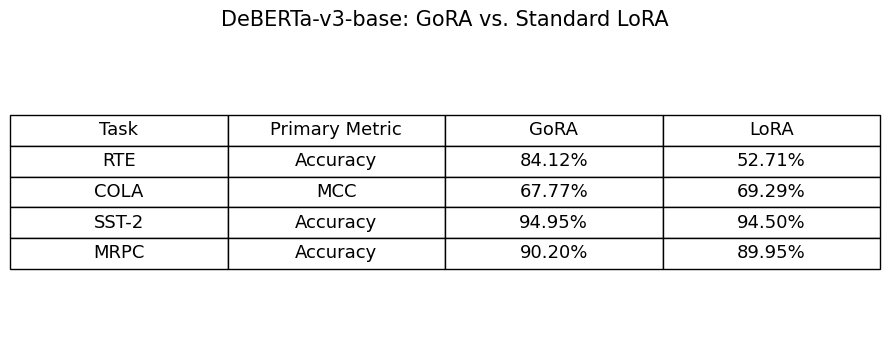

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# RESULTS — THIRD SEED
# ============================================================

results = {
    "Task": [
        "RTE",
        "COLA",
        "SST-2",
        "MRPC",
    ],

    "Metric": [
        "Accuracy",
        "MCC",
        "Accuracy",
        "Accuracy",
    ],

    "GoRA": [
        0.8412,
        0.6777,
        0.9495,
        0.9020,
    ],

    "LoRA": [
        0.5271,
        0.6929,
        0.9450,
        0.8995,
    ],
}

df = pd.DataFrame(results)

# Convert to percentage
df["GoRA"] = df["GoRA"] * 100
df["LoRA"] = df["LoRA"] * 100


# ============================================================
# DISPLAY TABLE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 3.5))

ax.axis("off")

table = ax.table(
    cellText=[
        [
            row["Task"],
            row["Metric"],
            f"{row['GoRA']:.2f}%",
            f"{row['LoRA']:.2f}%",
        ]
        for _, row in df.iterrows()
    ],

    colLabels=[
        "Task",
        "Primary Metric",
        "GoRA",
        "LoRA",
    ],

    loc="center",

    cellLoc="center",

    colLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.8)

plt.title(
    "DeBERTa-v3-base: GoRA vs. Standard LoRA",
    fontsize=15,
    pad=20,
)

plt.tight_layout()

plt.show()